# Question (a)
 ### Make a plot showing the measured hole locations d<sub>i</sub> ∈ R<sup>2</sup> in the x-y plane, where i labels the holes, indicating clearly which holes are in each fractured section of the ring.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
import numpy as np

# Load the data
file_path = "../dataverse_files/1-Fragment_C_Hole_Measurements.csv"
data = pd.read_csv(file_path)

# Extract info on hole section, hole number, with respective x-y coordinates
selected_columns = [data.columns[0], data.columns[1], data.columns[-2], data.columns[-1]]
data_array = data[selected_columns].to_numpy()

# Extract unique sections from the data
sections = np.unique(data_array[:, 0])

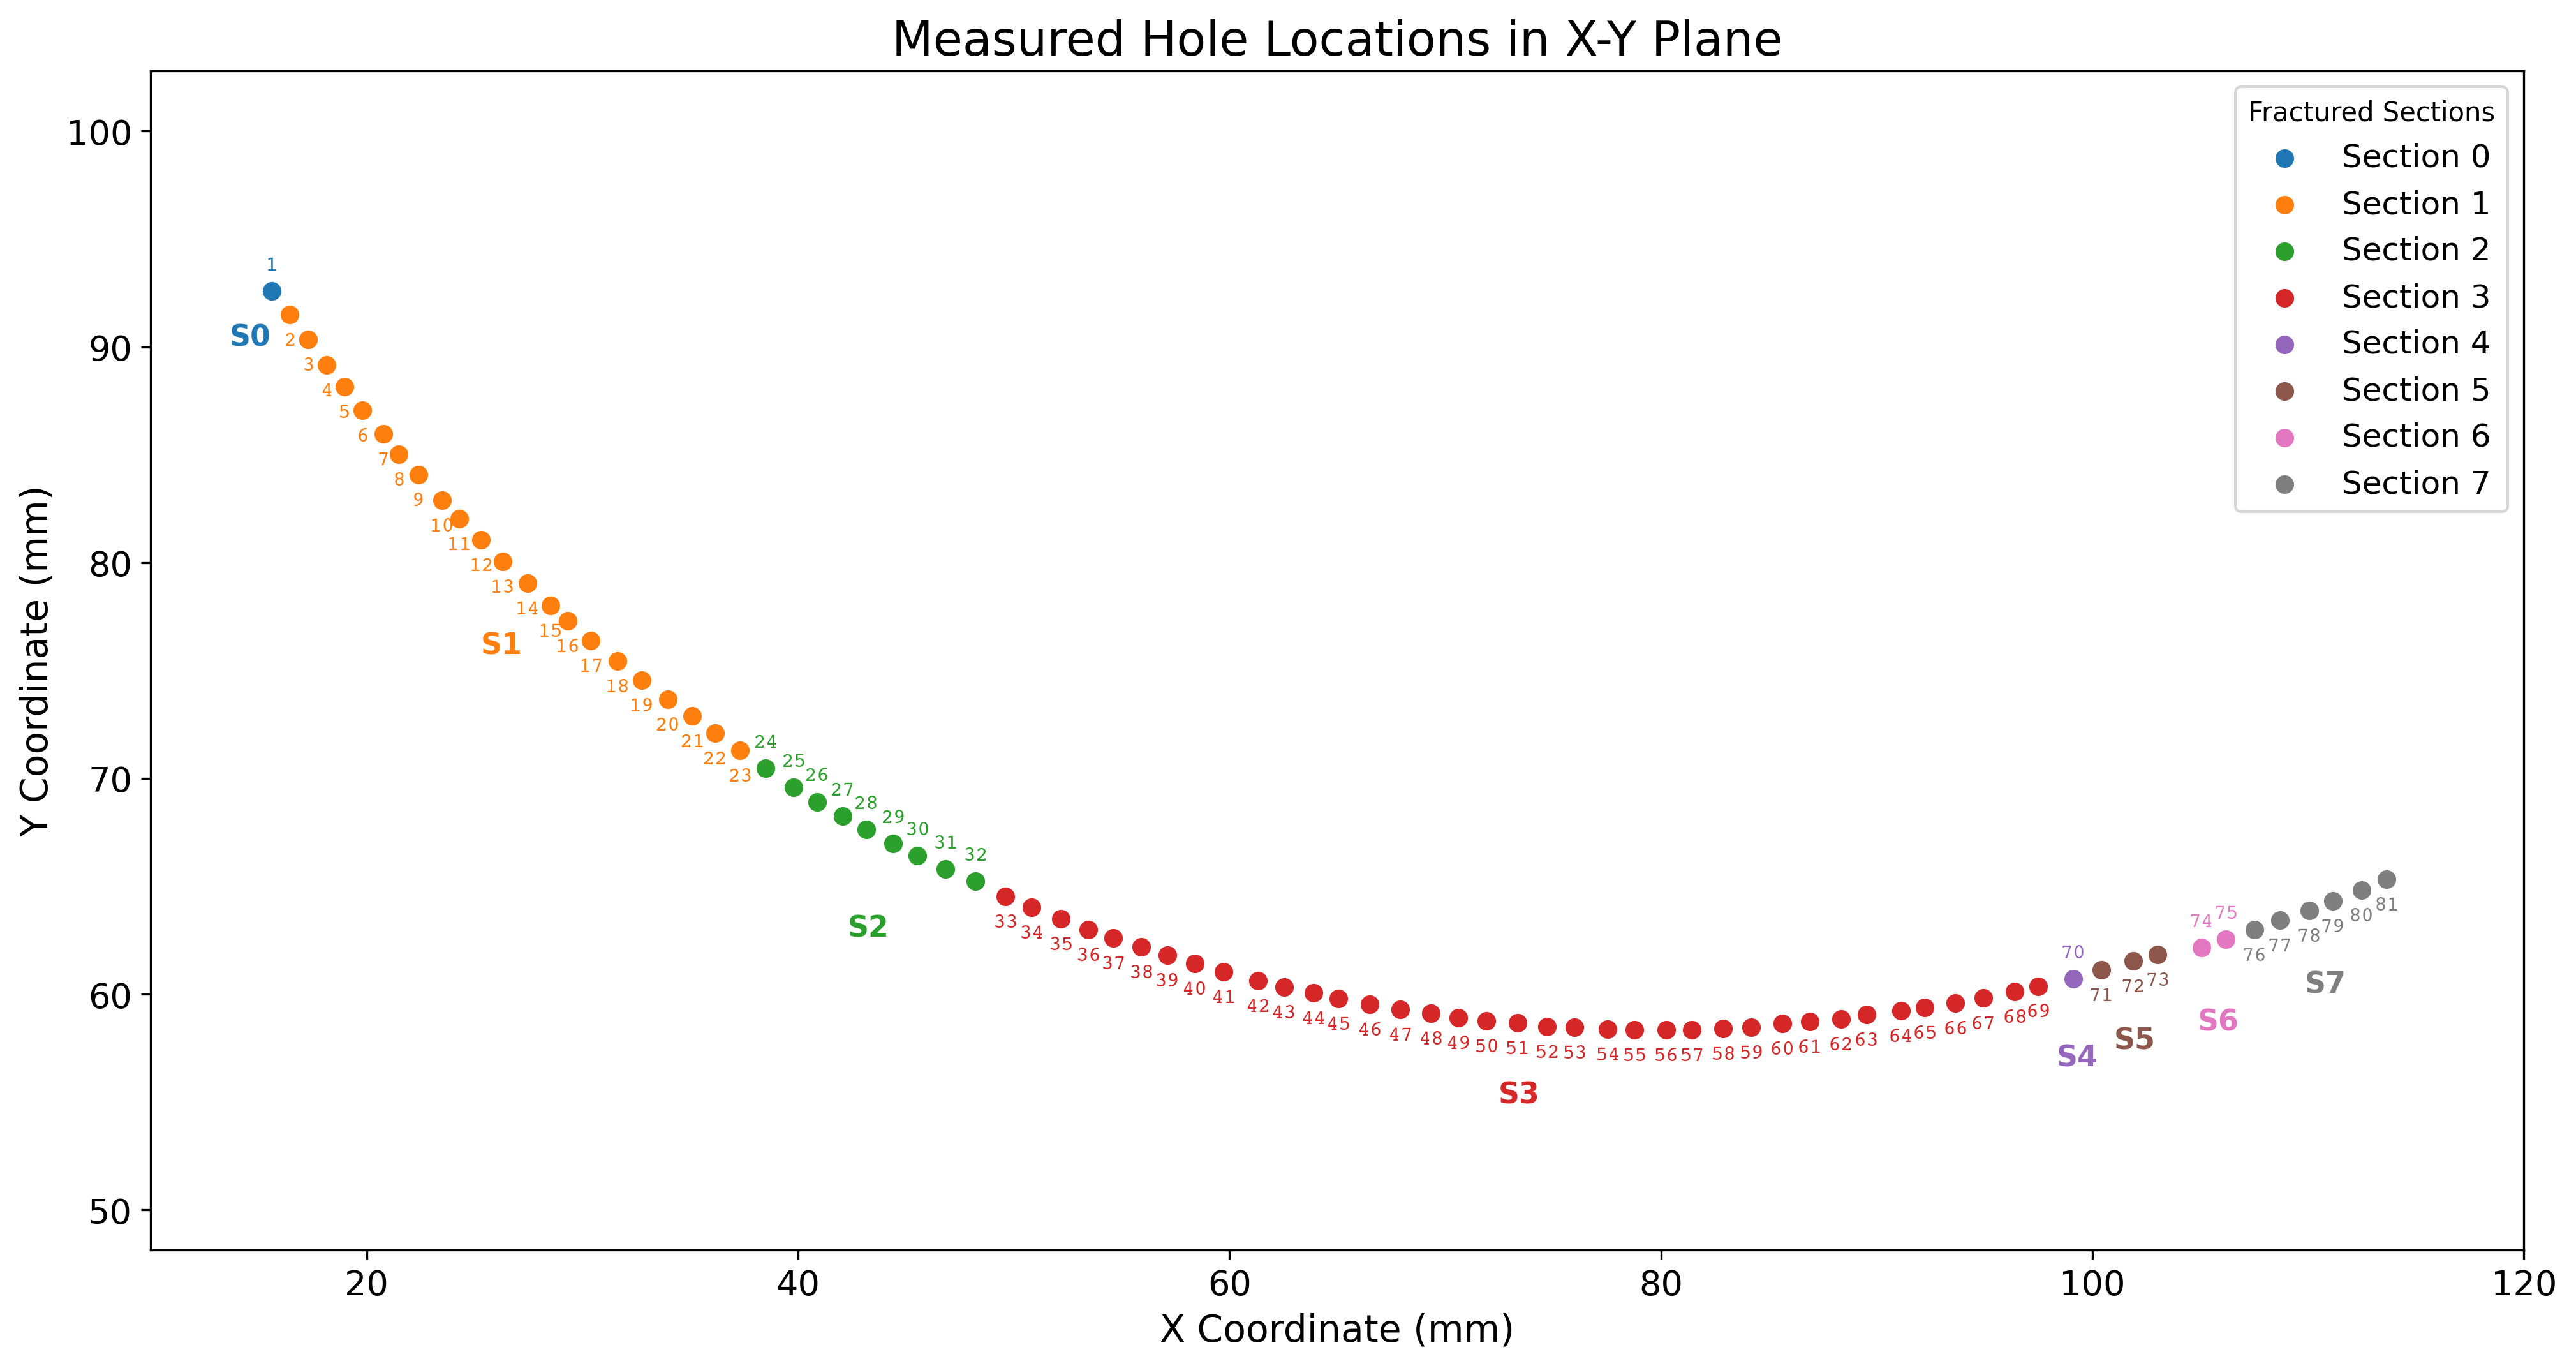

In [2]:
# Define colormap and select colors
cmap = plt.get_cmap("tab20")
selected_colors = [cmap(i) for i in range(0, 16, 2)]
# Offset for numbering annotations
offset = 0.8

# Set up the plot
plt.figure(figsize=(16, 8), dpi=300)

# Loop through each section and plot its data
for i, section in enumerate(sections):
    # Filter data for the current section
    section_data = data_array[data_array[:, 0] == section]

    # Scatter plot for the current section
    plt.scatter(section_data[:, 2], section_data[:, 3], 
                label=f"Section {int(section)}", color=selected_colors[i])

    # Calculate the mean position for section annotation
    x_section, y_section = np.mean(section_data[:, 2]), np.mean(section_data[:, 3])

    # Annotate each hole with its ID
    for row in section_data:
        y_offset = offset if section % 2 == 0 else -offset
        plt.text(row[2], row[3] + y_offset, str(int(row[1])),  
                 fontsize=8, color=selected_colors[i], ha="center",
                 va="bottom" if y_offset > 0 else "top", fontfamily="Courier")

    # Annotate the section ID
    x_section_offset, y_section_offset = (1, 1.5) if i == 0 else (0, 4) if i <= 3 else (-0.2, 3)
    plt.text(x_section - x_section_offset, y_section - y_section_offset, f"S{int(section)}",  
             fontsize=11, fontweight="bold", color=selected_colors[i],
             ha="center", va="top")

# Add labels, title
plt.xlabel("X Coordinate (mm)", fontsize=14)
plt.ylabel("Y Coordinate (mm)", fontsize=14)
plt.title("Measured Hole Locations in X-Y Plane", fontsize=18)
plt.axis("equal")
plt.xlim(10, 120)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Add legend
plt.legend(title="Fractured Sections", loc="best", fontsize=12)

plt.show()

# Question (b)
### Construct the model for the hole locations.

**Parameters used**:

1. Ring radius $r$.

2. Original number of holes $N$.

3. (x<sub>j</sub> ,y<sub>j</sub>  ,α<sub>j</sub>) to describe each section of the ring.

**Functions**:

1. $\phi$: the angular position of the $i$-th hole in section $j$ (in radians). 

2. rij_unit/tij_unit: radial/tangential unit vectors for the hole at $\phi_{ij}$.

3. rij_predict: theoretical position of hole $i$ in section $j$.

4. eij: computes the error vector from measured to predicted position.


**All functions are defined in** `hole_model.py`

In [3]:
from hole_model import phi, rij_unit, tij_unit, rij_predict, eij

# Question (c)
### Construct the Gaussian likelihood functions of the each hole location (assume independent errors).

**Covariance matrix used**:

1. 2D isotropic Gaussian distribution with 1 standard deviation $\sigma$.

2. 2D anisotropic Gaussian distribution with 2 standard deviations $\sigma_{r}$ and $\sigma_{t}$ (radial and tangential directions).


**Functions**:

1. model_XY: computes likelihood under an isotropic Gaussian error model in the XY-plane. Assumes circular symmetry of uncertainty in Cartesian coordinates.

2. model_RT: computes likelihood under a anisotropic Gaussian model, where errors are decomposed into radial and tangential components using local basis vectors $\hat{r}_{ij}$ and $\hat{t}_{ij}$.


**All functions are defined in** `hole_model.py`

In [4]:
from hole_model import model_XY, model_RT

# Question (d)
### (1) Construct jax version of all functions defined before, then define the negative log-likelihood functions for both models.


**All functions are defined in** `hole_model.py`

In [5]:
from hole_model import phi_jax, rij_unit_jax, tij_unit_jax, rij_predict_jax, eij_jax
from hole_model import model_XY_jax, model_RT_jax
from hole_model import NLL_XY_for_jax, NLL_RT_for_jax

### (2) Perform automatic differentiation with jax.

In [6]:
from jax import grad

grad_nll_XY = grad(NLL_XY_for_jax)
grad_nll_RT = grad(NLL_RT_for_jax)

### (3) Test the accuracy of derivatives calculated using jax.

Define the test data.

In [7]:
import jax
import jax.numpy as jnp
from jax.test_util import check_grads

# Used filter data for the test to match the defined models
# Filter out the sections with 1 hole
filtered_data = data_array[(data_array[:, 0] != 0) & (data_array[:, 0] != 4)]
filtered_data_T = filtered_data.T

params_XY_test = jnp.array([
    360, 75, 0.5,             # N, r, sigma_iso
    80, 80, 80, 80, 80, 80,   # xj_k
    130, 130, 130, 130, 130, 130,  # yj_k
    -2.5, -2.5, -2.5, -2.5, -2.5, -2.5  # alphaj_k
], dtype=jnp.float32)

params_RT_test = jnp.array([
    360, 75, 0.5, 0.5,        # N, r, sigma_r, sigma_t
    80, 80, 80, 80, 80, 80,   # xj_k
    130, 130, 130, 130, 130, 130,  # yj_k
    -2.5, -2.5, -2.5, -2.5, -2.5, -2.5  # alphaj_k
], dtype=jnp.float32)


Check the gradient of the NLL_XY function (isotropic model).

In [8]:
print("Testing gradients for XY model...")
check_grads(lambda params: NLL_XY_for_jax(params, filtered_data_T), (params_XY_test,), order=1, modes=["fwd", "rev"], atol=5e-3, rtol=5e-3)
print("Passed gradient check.")

Testing gradients for XY model...
Passed gradient check.


Check the gradient of the NLL_RT function (anisotropic model).

In [9]:
print("Testing gradients for RT model...")
check_grads(lambda params: NLL_RT_for_jax(params, filtered_data_T), (params_RT_test,), order=1, modes=['fwd', 'rev'], atol=5e-3, rtol=5e-3)
print("Passed gradient check.")

Testing gradients for RT model...
Passed gradient check.


The above tests can also be run via `pytest`, by running the following command from the root directory of the project:

```bash
pytest -s tests/


# Question (e)
### Find the maximum likelihood parameters for both models.

In [10]:
# Filter out the sections with 1 hole
filtered_data = data_array[(data_array[:, 0] != 0) & (data_array[:, 0] != 4)]
filtered_data_T = filtered_data.T

### (1) Minimise NLL of model_XY (isotropic model).

In [ ]:
# (1) Prepare the functions for optimization
def loss_fn_XY(params):
    params = np.array(params, dtype=np.float64).copy()
    return float(NLL_XY_for_jax(params, filtered_data_T))

def grad_fn_XY(params):
    params = np.array(params, dtype=np.float64).copy()
    grad = grad_nll_XY(params, filtered_data_T)
    return np.array(grad, dtype=np.float64).copy()

# (2) Set initial parameters in jax array
init_params_XY = [
    360., 75., 0.5,  # N, r, sigma_iso
    80., 80., 80., 80., 80., 80.,  # xj_1 to xj_7
    130., 130., 130., 130., 130., 130.,  # yj_1 to yj_7
    -2.5, -2.5, -2.5, -2.5, -2.5, -2.5  # alphaj_1 to alphaj_7
]

In [ ]:
# (3) Optimize the parameters
from scipy.optimize import minimize

bounds_XY = [
    (300, 400), (0, 100), (1e-8, 3.0)] + [(50, 100)] * 6 + [(90, 150)] * 6 + [(-3.15, 3.15)] * 6


result_XY = minimize(
    loss_fn_XY,
    init_params_XY,
    method='L-BFGS-B',
    jac=grad_fn_XY,
    bounds=bounds_XY,
    options={'disp': True, 'maxiter': 1000}
)



RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           21     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.05261D+03    |proj g|=  7.50000D+01

At iterate    1    f=  1.27969D+03    |proj g|=  4.01662D+01

At iterate    2    f=  1.23846D+03    |proj g|=  4.01706D+01

At iterate    3    f=  1.05571D+03    |proj g|=  7.29876D+01

At iterate    4    f=  1.01157D+03    |proj g|=  4.25556D+01

At iterate    5    f=  1.00297D+03    |proj g|=  2.09270D+01

At iterate    6    f=  9.98392D+02    |proj g|=  2.19727D+01

At iterate    7    f=  9.97584D+02    |proj g|=  2.17605D+01

At iterate    8    f=  9.93994D+02    |proj g|=  1.99977D+01

At iterate    9    f=  9.88574D+02    |proj g|=  1.98596D+01

At iterate   10    f=  9.81937D+02    |proj g|=  1.98280D+01

At iterate   11    f=  5.15408D+02    |proj g|=  2.06878D+01

At iterate   12    f=  5.06664D+02    |proj g|=  1.76366D+01

At iterate   13    f=  5.0


   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.



           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   21    587    684    596     0     0   1.421D+01  -1.390D+02
  F =  -139.03782653808594     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


In [28]:
# (4) Demonstrate the optimization result
if result_XY.success:
    print(" MLE Fit for model_XY is successful!")
else:
    print(" MLE Fit for model_XY failed:", result_XY.message)

print("\n Fitted parameters for model_XY (in the same order as init_params):\n")

param_names_XY = [
    "N", "r", "sigma_iso",
    "xj_1", "xj_2", "xj_3", "xj_5", "xj_6", "xj_7",
    "yj_1", "yj_2", "yj_3", "yj_5", "yj_6", "yj_7",
    "alphaj_1", "alphaj_2", "alphaj_3", "alphaj_5", "alphaj_6", "alphaj_7"
]

for name, value in zip(param_names_XY, result_XY.x):
    print(f"{name:<10}: {value:.5f}")


 MLE Fit for model_XY is successful!

 Fitted parameters for model_XY (in the same order as init_params):

N         : 354.22651
r         : 77.16634
sigma_iso : 0.10032
xj_1      : 79.53601
xj_2      : 82.14795
xj_3      : 79.82979
xj_5      : 77.62433
xj_6      : 78.07628
xj_7      : 77.56620
yj_1      : 135.95734
yj_2      : 134.24290
yj_3      : 135.52847
yj_5      : 134.79778
yj_6      : 134.44579
yj_7      : 133.81919
alphaj_1  : -2.56088
alphaj_2  : -2.59617
alphaj_3  : -2.56021
alphaj_5  : -2.52969
alphaj_6  : -2.52728
alphaj_7  : -2.52081


### (2) Minimise NLL of model_RT (anisotropic model).

In [31]:
# (1) Prepare the functions for optimization
def loss_fn_RT(params):
    params = np.array(params, dtype=np.float64).copy()
    return float(NLL_RT_for_jax(params, filtered_data_T))

def grad_fn_RT(params):
    params = np.array(params, dtype=np.float64).copy()
    grad = grad_nll_RT(params, filtered_data_T)
    return np.array(grad, dtype=np.float64).copy()


# (2) Set initial parameters in jax array
init_params_RT = [
    360, 75, 0.5, 0.5,  # N, r, sigma_r, sigma_t
    80, 80, 80, 80, 80, 80,  # xj_1 to xj_7
    130, 130, 130, 130, 130, 130,  # yj_1 to yj_7
    -2.5, -2.5, -2.5, -2.5, -2.5, -2.5  # alphaj_1 to alphaj_7
]

In [34]:
# (3) Optimize the parameters
bounds_RT = [(300, 400), (0, 100), (1e-8, 3.0),(1e-8, 3.0)] + [(50, 100)] * 6 + [(90, 150)] * 6 + [(-3.15, 3.15)] * 6

result_RT = minimize(
    loss_fn_RT,
    init_params_RT,
    method='L-BFGS-B',
    jac=grad_fn_RT,
    bounds=bounds_RT,
    options={'disp': True, 'maxiter': 10000}
)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           22     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.05261D+03    |proj g|=  7.50000D+01

At iterate    1    f=  1.27969D+03    |proj g|=  4.01662D+01

At iterate    2    f=  1.23900D+03    |proj g|=  4.01705D+01

At iterate    3    f=  1.05732D+03    |proj g|=  7.29872D+01

At iterate    4    f=  1.01318D+03    |proj g|=  4.33883D+01

At iterate    5    f=  1.00570D+03    |proj g|=  2.17115D+01

At iterate    6    f=  1.00041D+03    |proj g|=  2.29498D+01

At iterate    7    f=  9.99740D+02    |proj g|=  2.29439D+01

At iterate    8    f=  9.96357D+02    |proj g|=  2.24096D+01

At iterate    9    f=  9.90724D+02    |proj g|=  2.19768D+01

At iterate   10    f=  9.81193D+02    |proj g|=  2.36104D+01

At iterate   11    f=  5.34942D+02    |proj g|=  3.49263D+01
  Positive dir derivative in projection 
  Using the backtracking step 

At iterate   12 


   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.



           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   22   1432   1579   1442     0     0   1.146D+01  -2.236D+02
  F =  -223.56948852539062     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


In [35]:
# (4) Demonstrate the optimization result
if result_RT.success:
    print("MLE Fit for model_RT is successful!")
else:
    print("MLE Fit for model_RT failed:", result_RT.message)

print("\nFitted parameters for model_RT (in the same order as init_params):\n")


param_names_RT = [
    "N", "r", "sigma_r", "sigma_t",
    "xj_1", "xj_2", "xj_3", "xj_5", "xj_6", "xj_7",
    "yj_1", "yj_2", "yj_3", "yj_5", "yj_6", "yj_7",
    "alphaj_1", "alphaj_2", "alphaj_3", "alphaj_5", "alphaj_6", "alphaj_7"
]

for name, value in zip(param_names_RT, result_RT.x):
    print(f"{name:<10}: {value:.5f}")

MLE Fit for model_RT is successful!

Fitted parameters for model_RT (in the same order as init_params):

N         : 355.16226
r         : 77.38981
sigma_r   : 0.02814
sigma_t   : 0.12210
xj_1      : 79.72679
xj_2      : 79.98630
xj_3      : 79.86801
xj_5      : 78.44271
xj_6      : 78.20118
xj_7      : 82.57189
yj_1      : 136.06885
yj_2      : 135.73355
yj_3      : 135.76006
yj_5      : 135.27953
yj_6      : 134.72851
yj_7      : 136.22827
alphaj_1  : -2.56106
alphaj_2  : -2.56104
alphaj_3  : -2.55807
alphaj_5  : -2.53833
alphaj_6  : -2.52663
alphaj_7  : -2.58894


### (3) Plot the predictions for comparison.

In [41]:
# Predict hole positions using the fitted models
from hole_model import predict_hole_pos

prediction_model_XY = predict_hole_pos(filtered_data, result_XY.x, "XY")
prediction_model_RT = predict_hole_pos(filtered_data, result_RT.x, "RT")

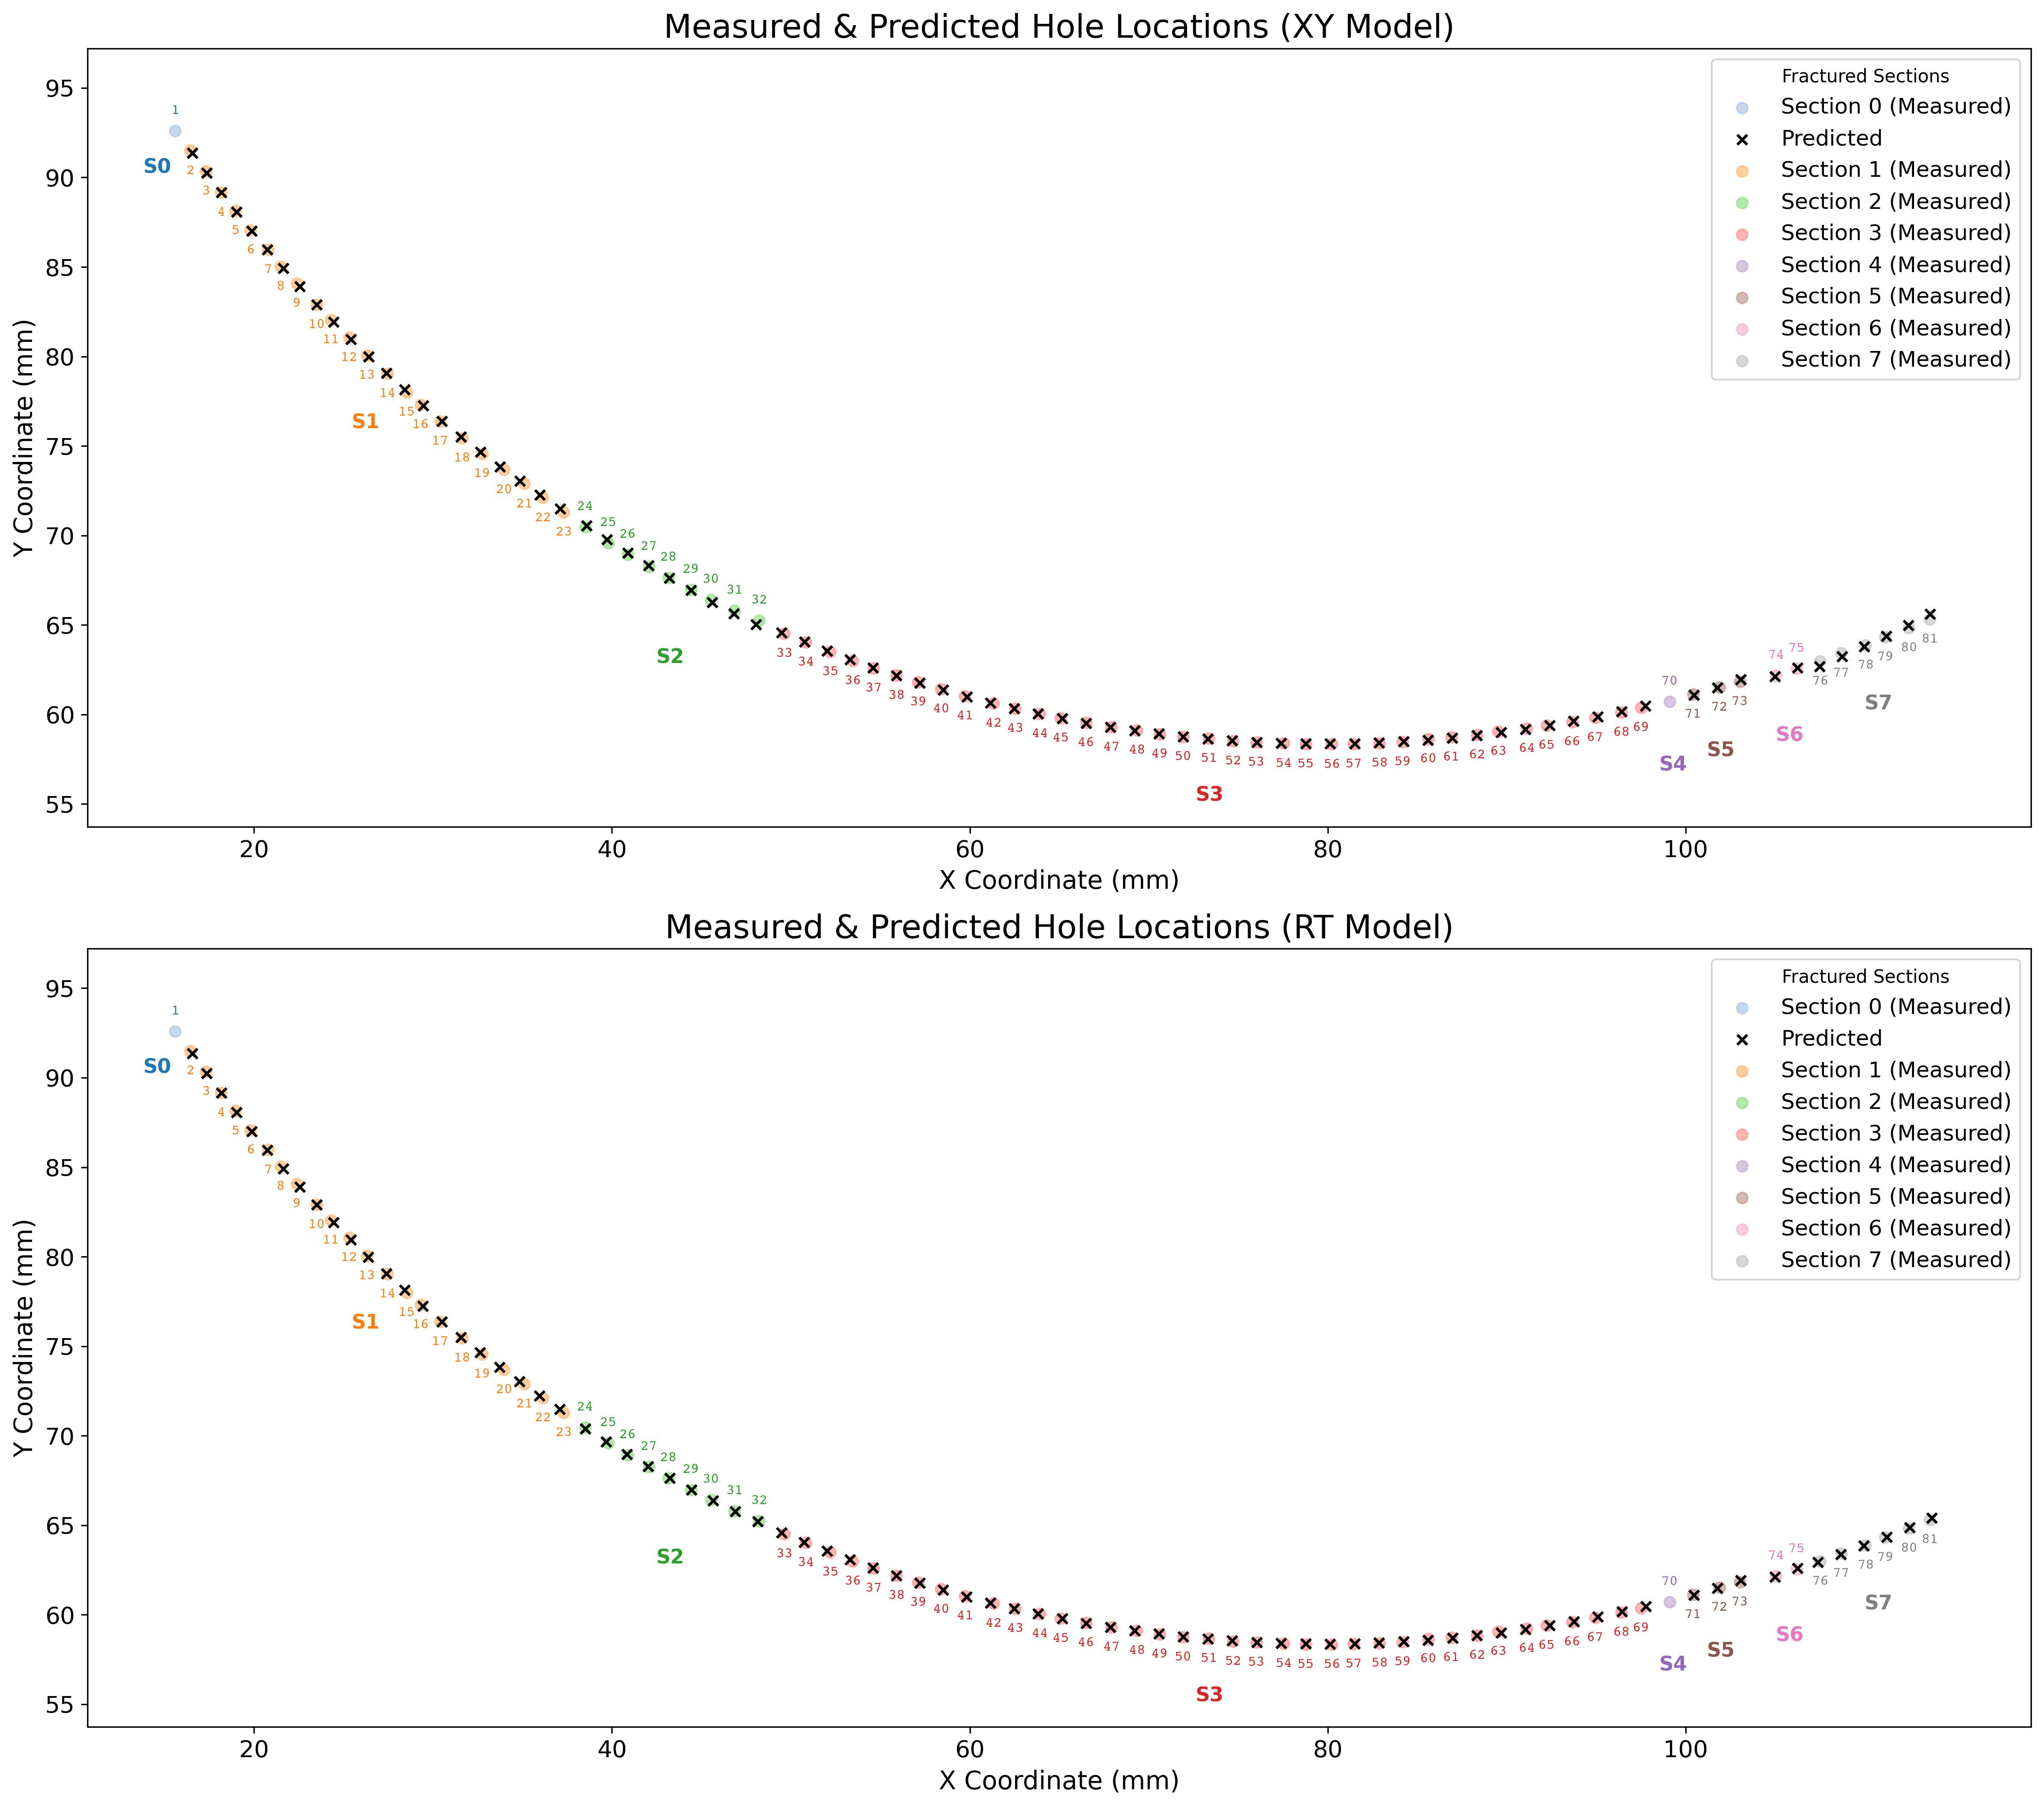

In [42]:
# Plot measured & predicted hole positions for XY model (top) and RT model (bottom)

sections = np.unique(data_array[:, 0])

# Define colormap and styles
cmap = plt.get_cmap("tab20")
colors_measured = [cmap(i) for i in range(1, 17, 2)]
colors_text = [cmap(i) for i in range(0, 16, 2)]
offset = 0.8

fig, axes = plt.subplots(2, 1, figsize=(16, 14), dpi=300)

# --- Subplot 1: XY model ---
ax1 = axes[0]
for i, section in enumerate(sections):
    section_data = data_array[data_array[:, 0] == section]
    x_meas, y_meas = section_data[:, 2], section_data[:, 3]
    section_pred = prediction_model_XY[prediction_model_XY[:, 0] == section]
    x_pred, y_pred = section_pred[:, 2], section_pred[:, 3]

    ax1.scatter(x_meas, y_meas, label=f"Section {int(section)} (Measured)",
                color=colors_measured[i], alpha=0.7)
    if i == 0:
        ax1.scatter(x_pred, y_pred, marker='x', s=30, color="black", label="Predicted")
    else:
        ax1.scatter(x_pred, y_pred, marker='x', s=30, color="black")

    y_offset = offset if section % 2 == 0 else -offset
    for row in section_data:
        ax1.text(row[2], row[3] + y_offset, str(int(row[1])),
                 fontsize=8, color=colors_text[i], fontfamily="Courier",
                 ha="center", va="bottom" if y_offset > 0 else "top")

    x_sec, y_sec = np.mean(x_meas), np.mean(y_meas)
    x_offset, y_sec_offset = (1, 1.5) if i == 0 else (0, 4) if i <= 3 else (-0.2, 3)
    ax1.text(x_sec - x_offset, y_sec - y_sec_offset, f"S{int(section)}",
             fontsize=11, fontweight="bold", color=colors_text[i],
             ha="center", va="top")

ax1.set_title("Measured & Predicted Hole Locations (XY Model)", fontsize=18)
ax1.set_xlabel("X Coordinate (mm)", fontsize=14)
ax1.set_ylabel("Y Coordinate (mm)", fontsize=14)
ax1.axis("equal")
ax1.set_xlim(10, 120)
ax1.tick_params(labelsize=13)
ax1.legend(title="Fractured Sections", loc="best", fontsize=12)

# --- Subplot 2: RT model ---
ax2 = axes[1]
for i, section in enumerate(sections):
    section_data = data_array[data_array[:, 0] == section]
    x_meas, y_meas = section_data[:, 2], section_data[:, 3]
    section_pred = prediction_model_RT[prediction_model_RT[:, 0] == section]
    x_pred, y_pred = section_pred[:, 2], section_pred[:, 3]

    ax2.scatter(x_meas, y_meas, label=f"Section {int(section)} (Measured)",
                color=colors_measured[i], alpha=0.7)
    if i == 0:
        ax2.scatter(x_pred, y_pred, marker='x', s=30, color="black", label="Predicted")
    else:
        ax2.scatter(x_pred, y_pred, marker='x', s=30, color="black")

    y_offset = offset if section % 2 == 0 else -offset
    for row in section_data:
        ax2.text(row[2], row[3] + y_offset, str(int(row[1])),
                 fontsize=8, color=colors_text[i], fontfamily="Courier",
                 ha="center", va="bottom" if y_offset > 0 else "top")

    x_sec, y_sec = np.mean(x_meas), np.mean(y_meas)
    x_offset, y_sec_offset = (1, 1.5) if i == 0 else (0, 4) if i <= 3 else (-0.2, 3)
    ax2.text(x_sec - x_offset, y_sec - y_sec_offset, f"S{int(section)}",
             fontsize=11, fontweight="bold", color=colors_text[i],
             ha="center", va="top")

ax2.set_title("Measured & Predicted Hole Locations (RT Model)", fontsize=18)
ax2.set_xlabel("X Coordinate (mm)", fontsize=14)
ax2.set_ylabel("Y Coordinate (mm)", fontsize=14)
ax2.axis("equal")
ax2.set_xlim(10, 120)
ax2.tick_params(labelsize=13)
ax2.legend(title="Fractured Sections", loc="best", fontsize=12)

plt.tight_layout()
plt.show()


### (4) Extra: MLE is also performed using `iminuit` to double-confirm the above fitting procedures and outcomes.

In [38]:
from iminuit.cost import UnbinnedNLL
from iminuit import Minuit

In [39]:
nll_XY = UnbinnedNLL(filtered_data_T, model_XY)


mi_XY = Minuit(nll_XY, N = 360, r = 75, sigma_iso = 0.5,
            xj_1 = 80, xj_2 = 80, xj_3 = 80, xj_5 = 80, xj_6 = 80, xj_7 = 80,
            yj_1 = 130, yj_2 = 130, yj_3 = 130, yj_5 = 130, yj_6 = 130, yj_7 = 130,
            alphaj_1 = -2.5, alphaj_2 = -2.5, alphaj_3 = -2.5, alphaj_5 = -2.5, alphaj_6 = -2.5, alphaj_7 = -2.5)


mi_XY.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -318.4                     │             Nfcn = 3795              │
│ EDM = 4.25e-05 (Goal: 0.0002)    │            time = 0.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name      │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N         │    355    │     4     │            │            │         │         │       │
│ 1 │ r         │   77.3    │    0.9    │            │            │         │         │       │
│ 2 │ sigma_iso │   0.088   │   0.005   │            │            │         │         │       │
│ 3 │ xj_1      │   79.7    │    0.6    │            │            │         │         │       │
│ 4 │ xj_2      │   79.9    │    0.7    │            │            │         │         │       │
│ 5 │ xj_3      │   79.87   │   0.11    │            │            │         │         │       │
│ 6 │ xj_5      │   81.5    │    3.4    │            │            │         │         │       │
│ 7 │ xj_6      │    81     │     7     │            │            │         │         │       │
│ 8 │ xj_7      │   83.2    │    1.2    │            │            │         │         │       │
│ 9 │ yj_1      │   136.1   │    0.6    │            │            │         │         │       │
│ 10│ yj_2      │   135.7   │    0.8    │            │            │         │         │       │
│ 11│ yj_3      │   135.7   │    0.9    │            │            │         │         │       │
│ 12│ yj_5      │   136.1   │    1.3    │            │            │         │         │       │
│ 13│ yj_6      │   135.8   │    2.5    │            │            │         │         │       │
│ 14│ yj_7      │   136.4   │    0.9    │            │            │         │         │       │
│ 15│ alphaj_1  │  -2.5607  │  0.0033   │            │            │         │         │       │
│ 16│ alphaj_2  │   -2.56   │   0.01    │            │            │         │         │       │
│ 17│ alphaj_3  │  -2.558   │   0.010   │            │            │         │         │       │
│ 18│ alphaj_5  │   -2.58   │   0.05    │            │            │         │         │       │
│ 19│ alphaj_6  │   -2.57   │   0.10    │            │            │         │         │       │
│ 20│ alphaj_7  │  -2.597   │   0.022   │            │            │         │         │       │
└───┴───────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│           │         N         r sigma_iso      xj_1      xj_2      xj_3      xj_5      xj_6      xj_7      yj_1      yj_2      yj_3      yj_5      yj_6      yj_7  alphaj_1  alphaj_2  alphaj_3  alphaj_5  alphaj_6  alphaj_7 │
├───────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│         

In [40]:
nll_RT = UnbinnedNLL(filtered_data_T, model_RT)


mi_RT = Minuit(nll_RT, N = 360, r = 75, sigma_r = 0.5, sigma_t = 0.5, 
            xj_1 = 80, xj_2 = 80, xj_3 = 80, xj_5 = 80, xj_6 = 80, xj_7 = 80,
            yj_1 = 130, yj_2 = 130, yj_3 = 130, yj_5 = 130, yj_6 = 130, yj_7 = 130,
            alphaj_1 = -2.5, alphaj_2 = -2.5, alphaj_3 = -2.5, alphaj_5 = -2.5, alphaj_6 = -2.5, alphaj_7 = -2.5)


mi_RT.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -461.4                     │             Nfcn = 4810              │
│ EDM = 2.99e-05 (Goal: 0.0002)    │            time = 0.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name     │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N        │   355.2   │    1.3    │            │            │         │         │       │
│ 1 │ r        │   77.34   │   0.27    │            │            │         │         │       │
│ 2 │ sigma_r  │  0.0258   │  0.0021   │            │            │         │         │       │
│ 3 │ sigma_t  │   0.123   │   0.010   │            │            │         │         │       │
│ 4 │ xj_1     │   79.69   │   0.19    │            │            │         │         │       │
│ 5 │ xj_2     │   79.91   │   0.21    │            │            │         │         │       │
│ 6 │ xj_3     │  79.860   │   0.032   │            │            │         │         │       │
│ 7 │ xj_5     │   81.4    │    1.0    │            │            │         │         │       │
│ 8 │ xj_6     │   81.5    │    2.3    │            │            │         │         │       │
│ 9 │ xj_7     │   83.22   │   0.35    │            │            │         │         │       │
│ 10│ yj_1     │  136.03   │   0.20    │            │            │         │         │       │
│ 11│ yj_2     │  135.72   │   0.25    │            │            │         │         │       │
│ 12│ yj_3     │  135.71   │   0.27    │            │            │         │         │       │
│ 13│ yj_5     │   136.1   │    0.4    │            │            │         │         │       │
│ 14│ yj_6     │   135.8   │    0.8    │            │            │         │         │       │
│ 15│ yj_7     │  136.42   │   0.28    │            │            │         │         │       │
│ 16│ alphaj_1 │  -2.5610  │  0.0011   │            │            │         │         │       │
│ 17│ alphaj_2 │  -2.5602  │  0.0031   │            │            │         │         │       │
│ 18│ alphaj_3 │  -2.5578  │  0.0033   │            │            │         │         │       │
│ 19│ alphaj_5 │  -2.578   │   0.014   │            │            │         │         │       │
│ 20│ alphaj_6 │  -2.571   │   0.031   │            │            │         │         │       │
│ 21│ alphaj_7 │  -2.597   │   0.007   │            │            │         │         │       │
└───┴──────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│          │         N         r   sigma_r   sigma_t      xj_1      xj_2      xj_3      xj_5      xj_6      xj_7      yj_1      yj_2      yj_3      yj_5      yj_6      yj_7  alphaj_1  alphaj_2  alphaj_3  alphaj_5  alphaj_6  alphaj_7 │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

# Question (f)
### (1) Sample the posterior distribution for both models using any variation of the Hamiltonian Monte Carlo sampling algorithm. 

In [43]:
import blackjax
import jax
from jax import random, vmap
from functools import partial


# import pre-defined priors and posterior functions
from hole_model import log_prior_XY, log_posterior_XY, log_prior_RT, log_posterior_RT

# Fix the log posterior to only depend on params by fixing data
logprob_fn_XY = partial(log_posterior_XY, data=filtered_data_T)
logprob_fn_RT = partial(log_posterior_RT, data=filtered_data_T)

(a) Basic configuration

In [44]:
num_chains = 30
num_steps = 200000
ndim_XY = 21
ndim_RT = 22

# Create random keys for each chain and each step
main_key = random.PRNGKey(0)
chain_keys = random.split(main_key, num_chains)
subkeys_per_chain = vmap(lambda k: random.split(k, num_steps))(chain_keys)

# Single-chain sampling function
def run_single_chain(hmc_kernel, init_state, keys):
    """
    Run HMC sampling for a single chain using blackjax's kernel.
    
    Parameters:
    - hmc_kernel: blackjax.hmc instance with .step method
    - init_state: blackjax initialized state for one chain
    - keys: jax.random.split(key, num_steps) for one chain

    Returns:
    - positions: array of shape (num_steps, ndim)
    - accepts: boolean array of shape (num_steps,)
    """
    def one_step(state, key):
        new_state, info = hmc_kernel.step(key, state)
        return new_state, (new_state.position, info.is_accepted)

    final_state, (positions, accepts) = jax.lax.scan(one_step, init_state, keys)
    return positions, accepts


(b)(i) Run HMC on posterior of model_XY (with isotropic errors)

In [45]:
# Use identity mass matrix
identity_mass_XY = jnp.ones(ndim_XY)

# Set up HMC kernel for the XY model
hmc_XY = blackjax.hmc(
    logprob_fn_XY,
    step_size=0.0003,
    num_integration_steps=200,
    inverse_mass_matrix=identity_mass_XY
)


# Initialise multiple chains
base_init_XY = jnp.array(init_params_XY)
init_positions_XY = jnp.tile(base_init_XY, (num_chains, 1))
init_states_XY = vmap(hmc_XY.init)(init_positions_XY)

# Run all chains in parallel
run_chain_XY = lambda state, keys: run_single_chain(hmc_XY, state, keys)
positions_all_XY, accepts_all_XY = vmap(run_chain_XY)(init_states_XY, subkeys_per_chain)

# Output shapes:
# - positions_all_XY: (num_chains, num_steps, ndim)
# - accepts_all_XY:   (num_chains, num_steps)


(b)(ii) Determine and remove burn-in steps

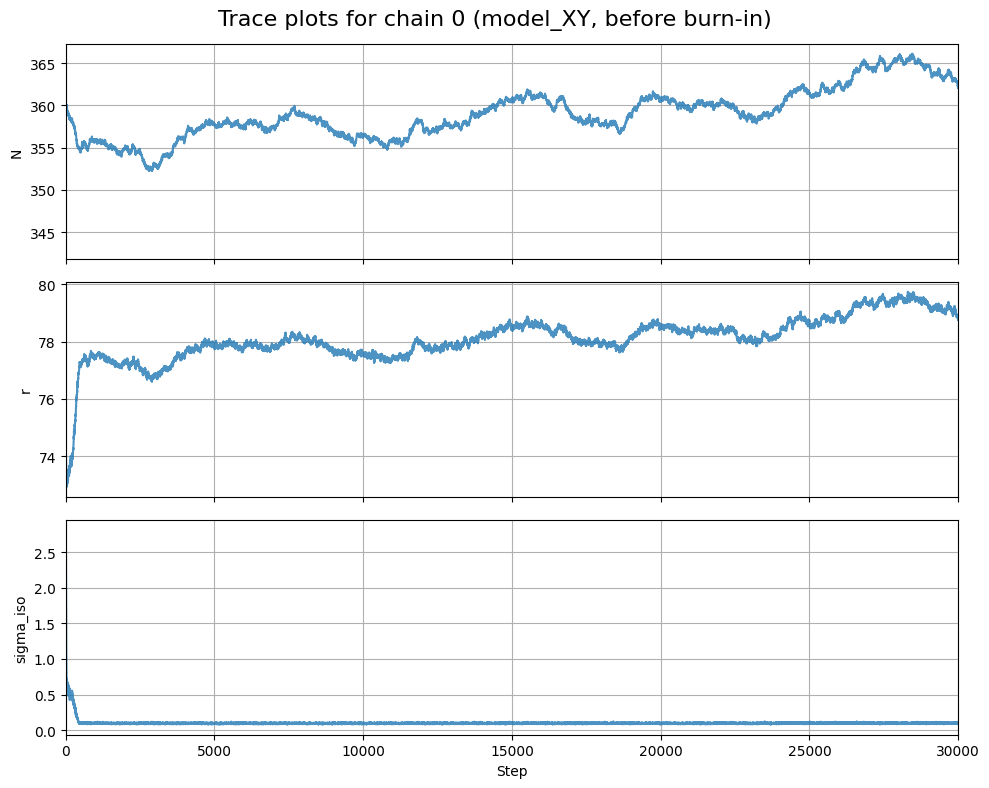

In [46]:
# Determine burn-in steps

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

param_XY_select = ["N", "r", "sigma_iso"]
param_indices_XY = [0,1,2]
chain_idx = 0

for ax, name, idx in zip(axes, param_XY_select, param_indices_XY):
    ax.plot(positions_all_XY[chain_idx, :, idx], alpha=0.8)
    ax.set_ylabel(name)
    ax.grid(True)
    ax.set_xlim(0, 30000)

axes[-1].set_xlabel("Step")
fig.suptitle(f"Trace plots for chain {chain_idx} (model_XY, before burn-in)", fontsize=16)
plt.tight_layout()
plt.show()


In [47]:
# Remove burn-in

burn_in_XY = 5000

samples_burned_XY = positions_all_XY[:, burn_in_XY:, :]  # shape (chains, steps, params)
accepts_burned_XY = accepts_all_XY[:, burn_in_XY:]

(b)(iii) Thinning

In [48]:
# Calculate autocorrelation time

from zeus import AutoCorrTime

taus = AutoCorrTime(np.array(samples_burned_XY))
print("Autocorrelation times for all parameters in model_XY HMC:")
print(taus)

tau = max(taus)
print(f"\nMaximum autocorrelation time across all parameters: tau = {tau:.2f}")

Autocorrelation times for all parameters in model_XY HMC:
[0.8667779  0.86462545 0.99943984 0.87194216 0.90299487 0.93730485
 0.74015534 1.04333735 0.89287126 0.86871314 0.91437078 0.86499107
 0.98000944 1.01662827 0.86036372 0.92335451 0.98922873 0.86498082
 0.69226062 1.07181954 0.89032543]

Maximum autocorrelation time across all parameters: tau = 1.07


In [49]:
# Apply thinning
thinning_factor = 5
samples_thinned_XY = samples_burned_XY[:, ::thinning_factor, :] 
accepts_thinned_XY = accepts_burned_XY[:, ::thinning_factor]

(b)(iv) Check acceeptance rate, trace plot and results

In [50]:
# Acceptance rate

overall_acceptance = accepts_thinned_XY.mean()
print(f"model_XY: Overall acceptance rate across all chains: {overall_acceptance:.3f}")


model_XY: Overall acceptance rate across all chains: 0.782


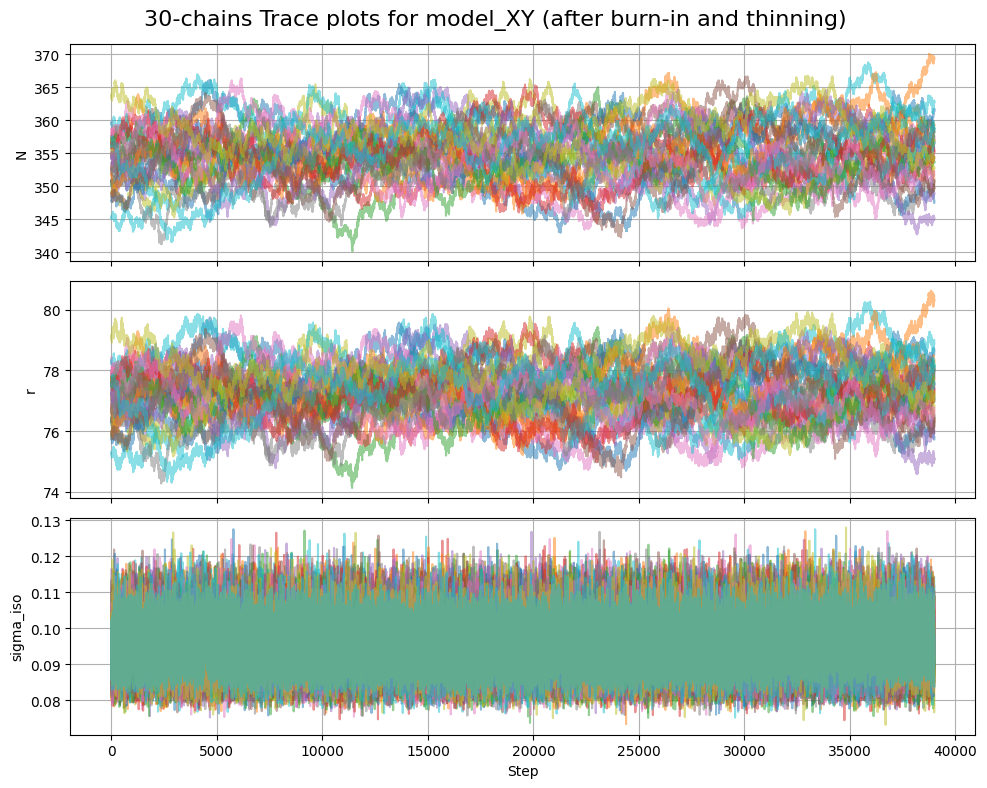

In [51]:
# Trace plots for N, r, sigma_iso

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

param_XY_select = ["N", "r", "sigma_iso"]
param_indices_XY = [0,1,2]

for ax, name, idx in zip(axes, param_XY_select, param_indices_XY):
    for chain in range(num_chains):
        ax.plot(samples_thinned_XY[chain, :, idx], alpha=0.5)
    ax.set_ylabel(name)
    ax.grid(True)

axes[-1].set_xlabel("Step")

fig.suptitle("30-chains Trace plots for model_XY (after burn-in and thinning)", fontsize=16)

plt.tight_layout()
plt.show()

In [52]:
param_names_XY = [
    "N", "r", "sigma_iso",
    "xj_1", "xj_2", "xj_3", "xj_5", "xj_6", "xj_7",
    "yj_1", "yj_2", "yj_3", "yj_5", "yj_6", "yj_7",
    "alphaj_1", "alphaj_2", "alphaj_3", "alphaj_5", "alphaj_6", "alphaj_7"
]


In [53]:
# Flatten samples for analysis
flat_samples_XY = samples_thinned_XY.reshape(-1, ndim_XY) # shape (n_samples, n_params) 
selected_XY = np.array(flat_samples_XY[:, [0,1,2]]) # N, r, sigma_iso
labels_XY = [r"$N$", r"$r$", r"$\sigma_iso$"]


# Show results
import arviz as az
import numpy as np
import xarray as xr

posterior_XY = {
    name: samples_thinned_XY[:, :, idx]
    for idx, name in enumerate(param_names_XY)
}


idata = az.from_dict(posterior=posterior_XY)


# Summary
summary_df = az.summary(idata, var_names=param_names_XY, round_to=2)

keep_cols = ["mean", "sd", "hdi_3%", "hdi_97%", "mcse_mean", "mcse_sd"]
summary_df[keep_cols]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd
N,354.99,4.19,347.24,362.97,0.36,0.25
r,77.29,0.90,75.62,79.01,0.08,0.05
sigma_iso,0.10,0.01,0.08,0.11,0.00,0.00
xj_1,79.64,0.65,78.44,80.86,0.05,0.04
xj_2,79.88,0.74,78.48,81.28,0.04,0.03
xj_3,79.86,0.11,79.65,80.08,0.01,0.00
xj_5,81.18,3.84,73.69,88.18,0.30,0.21
xj_6,81.13,7.40,68.05,96.22,0.91,0.65
xj_7,83.24,1.28,80.81,85.64,0.03,0.02
yj_1,136.02,0.67,134.78,137.28,0.06,0.04


In [54]:
# Check convergence using R-hat
from numpyro.diagnostics import gelman_rubin

for i, name in enumerate(param_names_XY):
    rhat = gelman_rubin(samples_thinned_XY[:, :, i])
    print(f"R-hat for {name}: {rhat:.3f}")


R-hat for N: 1.066
R-hat for r: 1.066
R-hat for sigma_iso: 1.001
R-hat for xj_1: 1.063
R-hat for xj_2: 1.024
R-hat for xj_3: 1.029
R-hat for xj_5: 1.056
R-hat for xj_6: 1.222
R-hat for xj_7: 1.012
R-hat for yj_1: 1.063
R-hat for yj_2: 1.054
R-hat for yj_3: 1.066
R-hat for yj_5: 1.063
R-hat for yj_6: 1.162
R-hat for yj_7: 1.050
R-hat for alphaj_1: 1.035
R-hat for alphaj_2: 1.018
R-hat for alphaj_3: 1.065
R-hat for alphaj_5: 1.057
R-hat for alphaj_6: 1.224
R-hat for alphaj_7: 1.036


(b)(v) Visualise by corner plot

<Figure size 3200x2400 with 0 Axes>

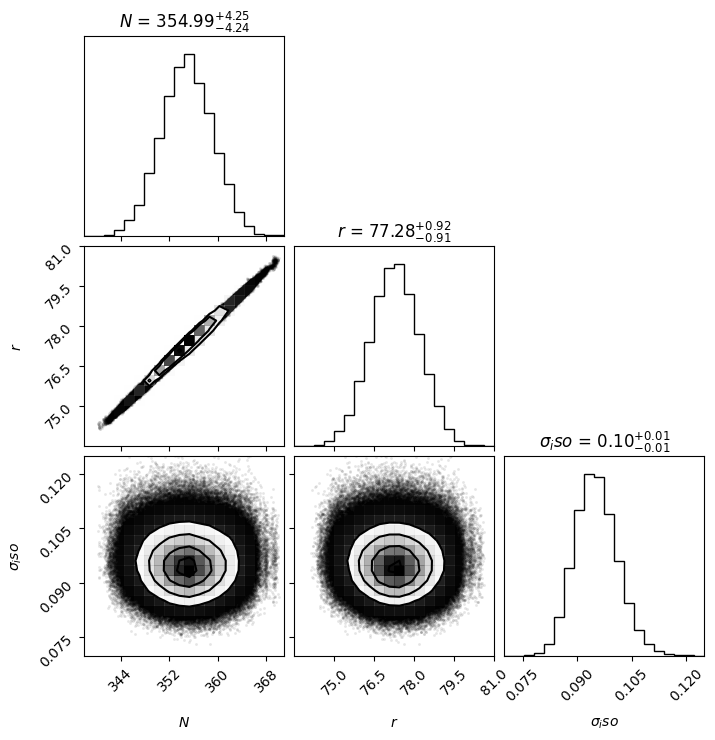

In [56]:
import corner

plt.figure(dpi=500)
fig = corner.corner(selected_XY, labels=labels_XY, show_titles=True
                    #,range=[(337, 372),(73, 81),(0.07, 0.125)]
                    ,range=[(338, 371),(73.5, 81),(0.07, 0.125)]
                    )

plt.show()

(c)(i) Run HMC on posterior of model_RT (with non-isotropic errors)

In [57]:
# Use identity mass matrix
identity_mass_RT = jnp.ones(ndim_RT)

# Set up HMC kernel for the RT model
hmc_RT = blackjax.hmc(
    logprob_fn_RT,
    step_size=0.0003,
    num_integration_steps=200,
    inverse_mass_matrix=identity_mass_RT
)


# Initialise multiple chains
base_init_RT = jnp.array(init_params_RT)
init_positions_RT = jnp.tile(base_init_RT, (num_chains, 1))
init_states_RT = vmap(hmc_RT.init)(init_positions_RT)
 

# Run all chains in parallel
run_chain_RT = lambda state, keys: run_single_chain(hmc_RT, state, keys)
positions_all_RT, accepts_all_RT = vmap(run_chain_RT)(init_states_RT, subkeys_per_chain)

# Output shapes:
# - positions_all_RT: (num_chains, num_steps, ndim)
# - accepts_all_RT:   (num_chains, num_steps)


(c)(ii) Determine and remove burn-in steps

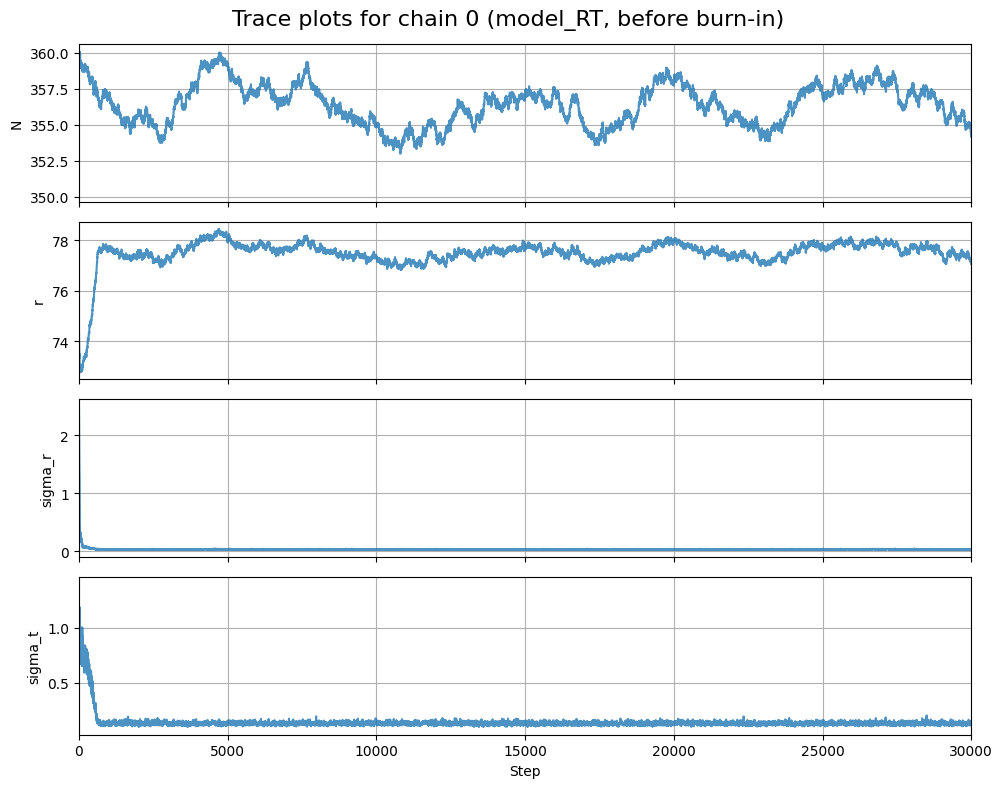

In [58]:
# Determine burn-in steps

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

param_RT_select = ["N", "r", "sigma_r", "sigma_t"]
param_indices_RT = [0,1,2,3]
chain_idx = 0

for ax, name, idx in zip(axes, param_RT_select, param_indices_RT):
    ax.plot(positions_all_RT[chain_idx, :, idx], alpha=0.8)
    ax.set_ylabel(name)
    ax.grid(True)
    ax.set_xlim(0, 30000)

axes[-1].set_xlabel("Step")
fig.suptitle(f"Trace plots for chain {chain_idx} (model_RT, before burn-in)", fontsize=16)
plt.tight_layout()
plt.show()


In [59]:
# Burn-in

burn_in = 5000

samples_burned_RT = positions_all_RT[:, burn_in:, :]  # shape (chains, steps, params)
accepts_burned_RT = accepts_all_RT[:, burn_in:]

(c)(iii) Thinning

In [60]:
# Calculate autocorrelation time

from zeus import AutoCorrTime

taus = AutoCorrTime(np.array(samples_burned_RT))
print("Autocorrelation times for all parameters in model_RT HMC:")
print(taus)

tau = max(taus)
print(f"\nMaximum autocorrelation time across all parameters: tau = {tau:.2f}")

Autocorrelation times for all parameters in model_RT HMC:
[0.96600223 0.9599607  0.99656308 1.0044241  0.96213353 0.9703536
 0.98122191 1.00943685 0.98525763 0.98959064 0.96053708 0.96257257
 0.95995986 0.99059093 0.92349386 0.9536258  0.97807479 0.98000574
 0.96579945 0.9876157  0.99771738 0.98719823]

Maximum autocorrelation time across all parameters: tau = 1.01


In [79]:
# Apply thinning
thinning_factor = 5
samples_thinned_RT = samples_burned_RT[:, ::thinning_factor, :] 
accepts_thinned_RT = accepts_burned_RT[:, ::thinning_factor]

(c)(iv) Check acceeptance rate, trace plot and results

In [80]:
# Acceptance rate

overall_acceptance = accepts_thinned_RT.mean()
print(f"model_RT: Overall acceptance rate across all chains: {overall_acceptance:.3f}")

model_RT: Overall acceptance rate across all chains: 0.901


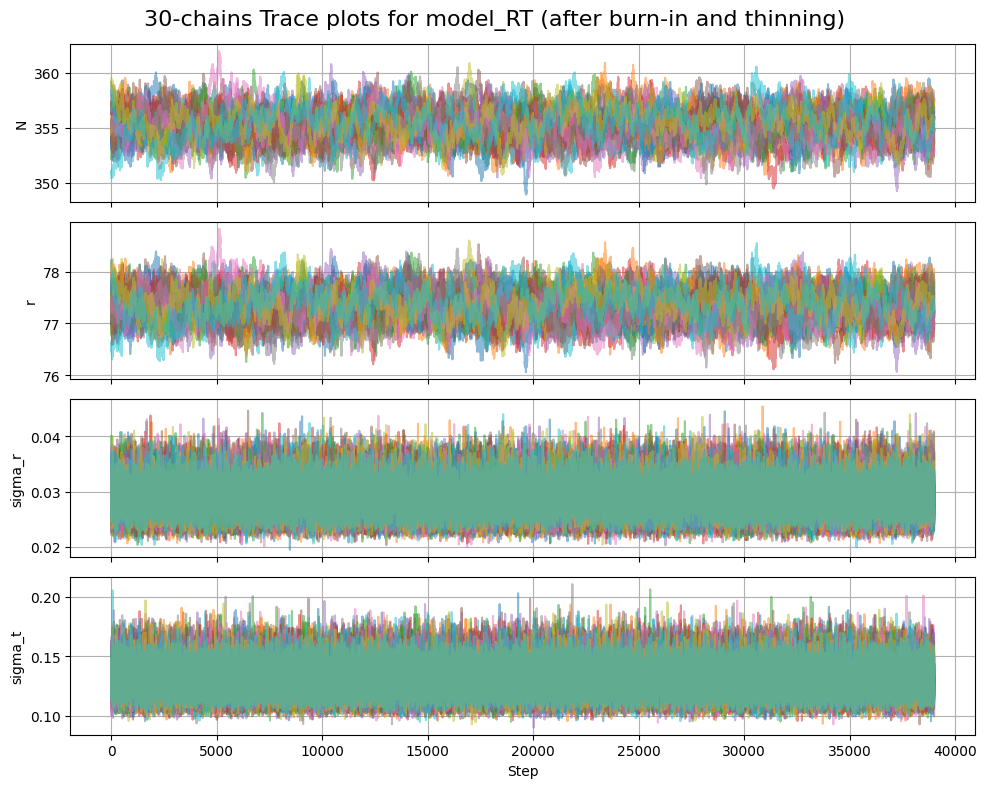

In [81]:
# Trace plots for N, r, sigma_r, sigma_t

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

param_RT_select = ["N", "r", "sigma_r", "sigma_t"]
param_indices_RT = [0,1,2,3]

for ax, name, idx in zip(axes, param_RT_select, param_indices_RT):
    for chain in range(num_chains):
        ax.plot(samples_thinned_RT[chain, :, idx], alpha=0.5)
    ax.set_ylabel(name)
    ax.grid(True)

axes[-1].set_xlabel("Step")

fig.suptitle("30-chains Trace plots for model_RT (after burn-in and thinning)", fontsize=16)

plt.tight_layout()
plt.show()

In [82]:
param_names_RT = [
    "N", "r", "sigma_r", "sigma_t",
    "xj_1", "xj_2", "xj_3", "xj_5", "xj_6", "xj_7",
    "yj_1", "yj_2", "yj_3", "yj_5", "yj_6", "yj_7",
    "alphaj_1", "alphaj_2", "alphaj_3", "alphaj_5", "alphaj_6", "alphaj_7"
]

In [83]:
# Flatten samples for analysis
flat_samples_RT = samples_thinned_RT.reshape(-1, ndim_RT) # shape (n_samples, n_params) 
selected_RT = np.array(flat_samples_RT[:, [0,1,2,3]]) # N, r, two sigmas
labels_RT = [r"$N$", r"$r$", r"$\sigma_r$", r"$\sigma_t$"]

# Show results
posterior_RT = {
    name: samples_thinned_RT[:, :, idx]
    for idx, name in enumerate(param_names_RT)
}


idata_RT = az.from_dict(posterior=posterior_RT)



# Summary
summary_df = az.summary(idata_RT, var_names=param_names_RT, round_to=2)
keep_cols = ["mean", "sd", "hdi_3%", "hdi_97%", "mcse_mean", "mcse_sd"]
summary_df[keep_cols]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd
N,355.24,1.41,352.59,357.90,0.03,0.02
r,77.34,0.29,76.80,77.88,0.01,0.00
sigma_r,0.03,0.00,0.02,0.03,0.00,0.00
sigma_t,0.13,0.01,0.11,0.15,0.00,0.00
xj_1,79.69,0.20,79.30,80.07,0.00,0.00
xj_2,79.91,0.23,79.47,80.34,0.00,0.00
xj_3,79.86,0.04,79.79,79.93,0.00,0.00
xj_5,81.45,1.13,79.32,83.58,0.02,0.01
xj_6,81.51,2.54,76.66,86.23,0.11,0.08
xj_7,83.22,0.39,82.48,83.96,0.00,0.00


In [84]:
# Check convergence using R-hat
from numpyro.diagnostics import gelman_rubin

for i, name in enumerate(param_names_RT):
    rhat = gelman_rubin(samples_thinned_RT[:, :, i])
    print(f"R-hat for {name}: {rhat:.3f}")


R-hat for N: 1.006
R-hat for r: 1.006
R-hat for sigma_r: 1.001
R-hat for sigma_t: 1.000
R-hat for xj_1: 1.005
R-hat for xj_2: 1.002
R-hat for xj_3: 1.003
R-hat for xj_5: 1.005
R-hat for xj_6: 1.024
R-hat for xj_7: 1.001
R-hat for yj_1: 1.005
R-hat for yj_2: 1.005
R-hat for yj_3: 1.006
R-hat for yj_5: 1.005
R-hat for yj_6: 1.021
R-hat for yj_7: 1.004
R-hat for alphaj_1: 1.003
R-hat for alphaj_2: 1.002
R-hat for alphaj_3: 1.006
R-hat for alphaj_5: 1.005
R-hat for alphaj_6: 1.023
R-hat for alphaj_7: 1.004


(c)(v) Visualise by corner plot

<Figure size 6400x4800 with 0 Axes>

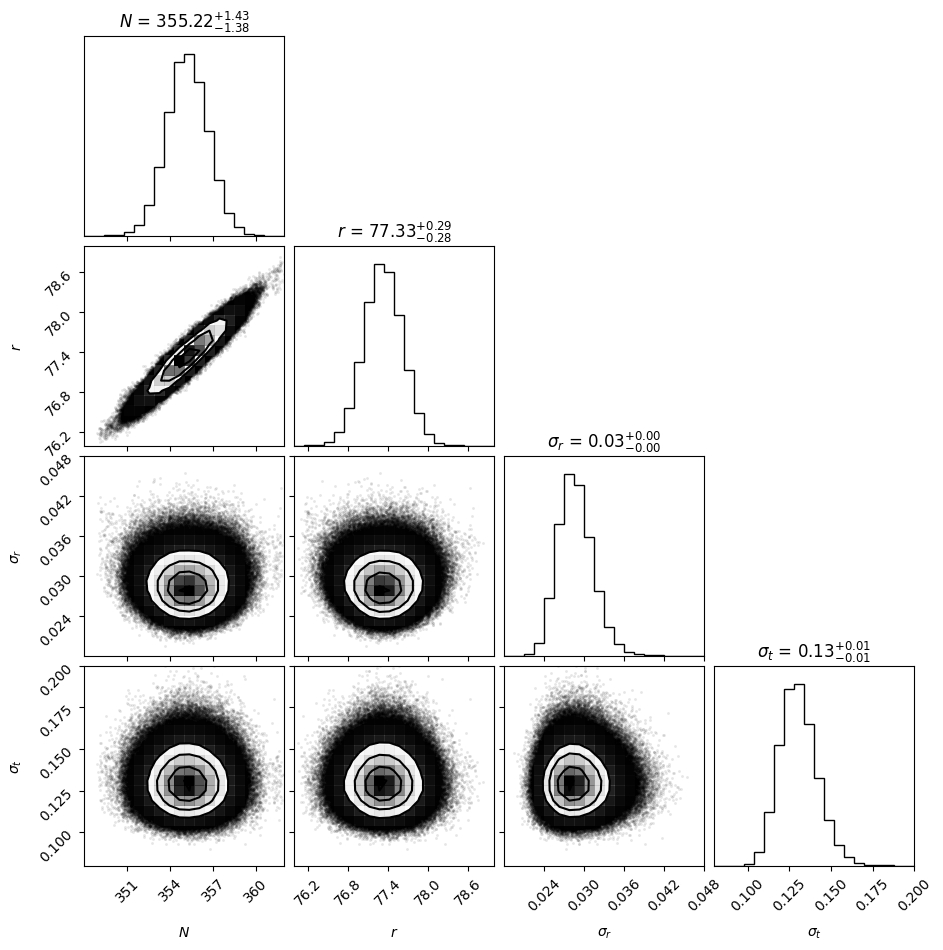

In [85]:
import corner

plt.figure(dpi=1000)
fig = corner.corner(selected_RT, labels=labels_RT, show_titles=True
                    ,range=[(348, 362), (76, 79), (0.018, 0.048), (0.08, 0.2)]
                    )

plt.show()

### (2) For Hole #41: show the posterior predictive distribution for both models.

In [86]:
input_sample = data_array[40]  # Section 3, index 41
input_sample

array([ 3.     , 41.     , 59.72639, 61.04306])

(a) Posterior Predictive Distribution model_XY (Hole #41)

In [87]:
from hole_model import posterior_predictive_XY

In [88]:
# Prediction
predictive_coordinates_XY = posterior_predictive_XY(flat_samples_XY, input_sample)

predictive_coordinates_XY.shape
# predictive_coordinates: shape (n_samples, 2)

(1170000, 2)

(b) Posterior Predictive Distribution model_RT (Hole #41)

In [89]:
from hole_model import posterior_predictive_RT

In [90]:
# Prediction
predictive_coordinates_RT = posterior_predictive_RT(flat_samples_RT, input_sample)

predictive_coordinates_RT.shape
# predictive_coordinates: shape (n_samples, 2)

(1170000, 2)

(c) Plotting: Posterior Predictive Distribution for both models

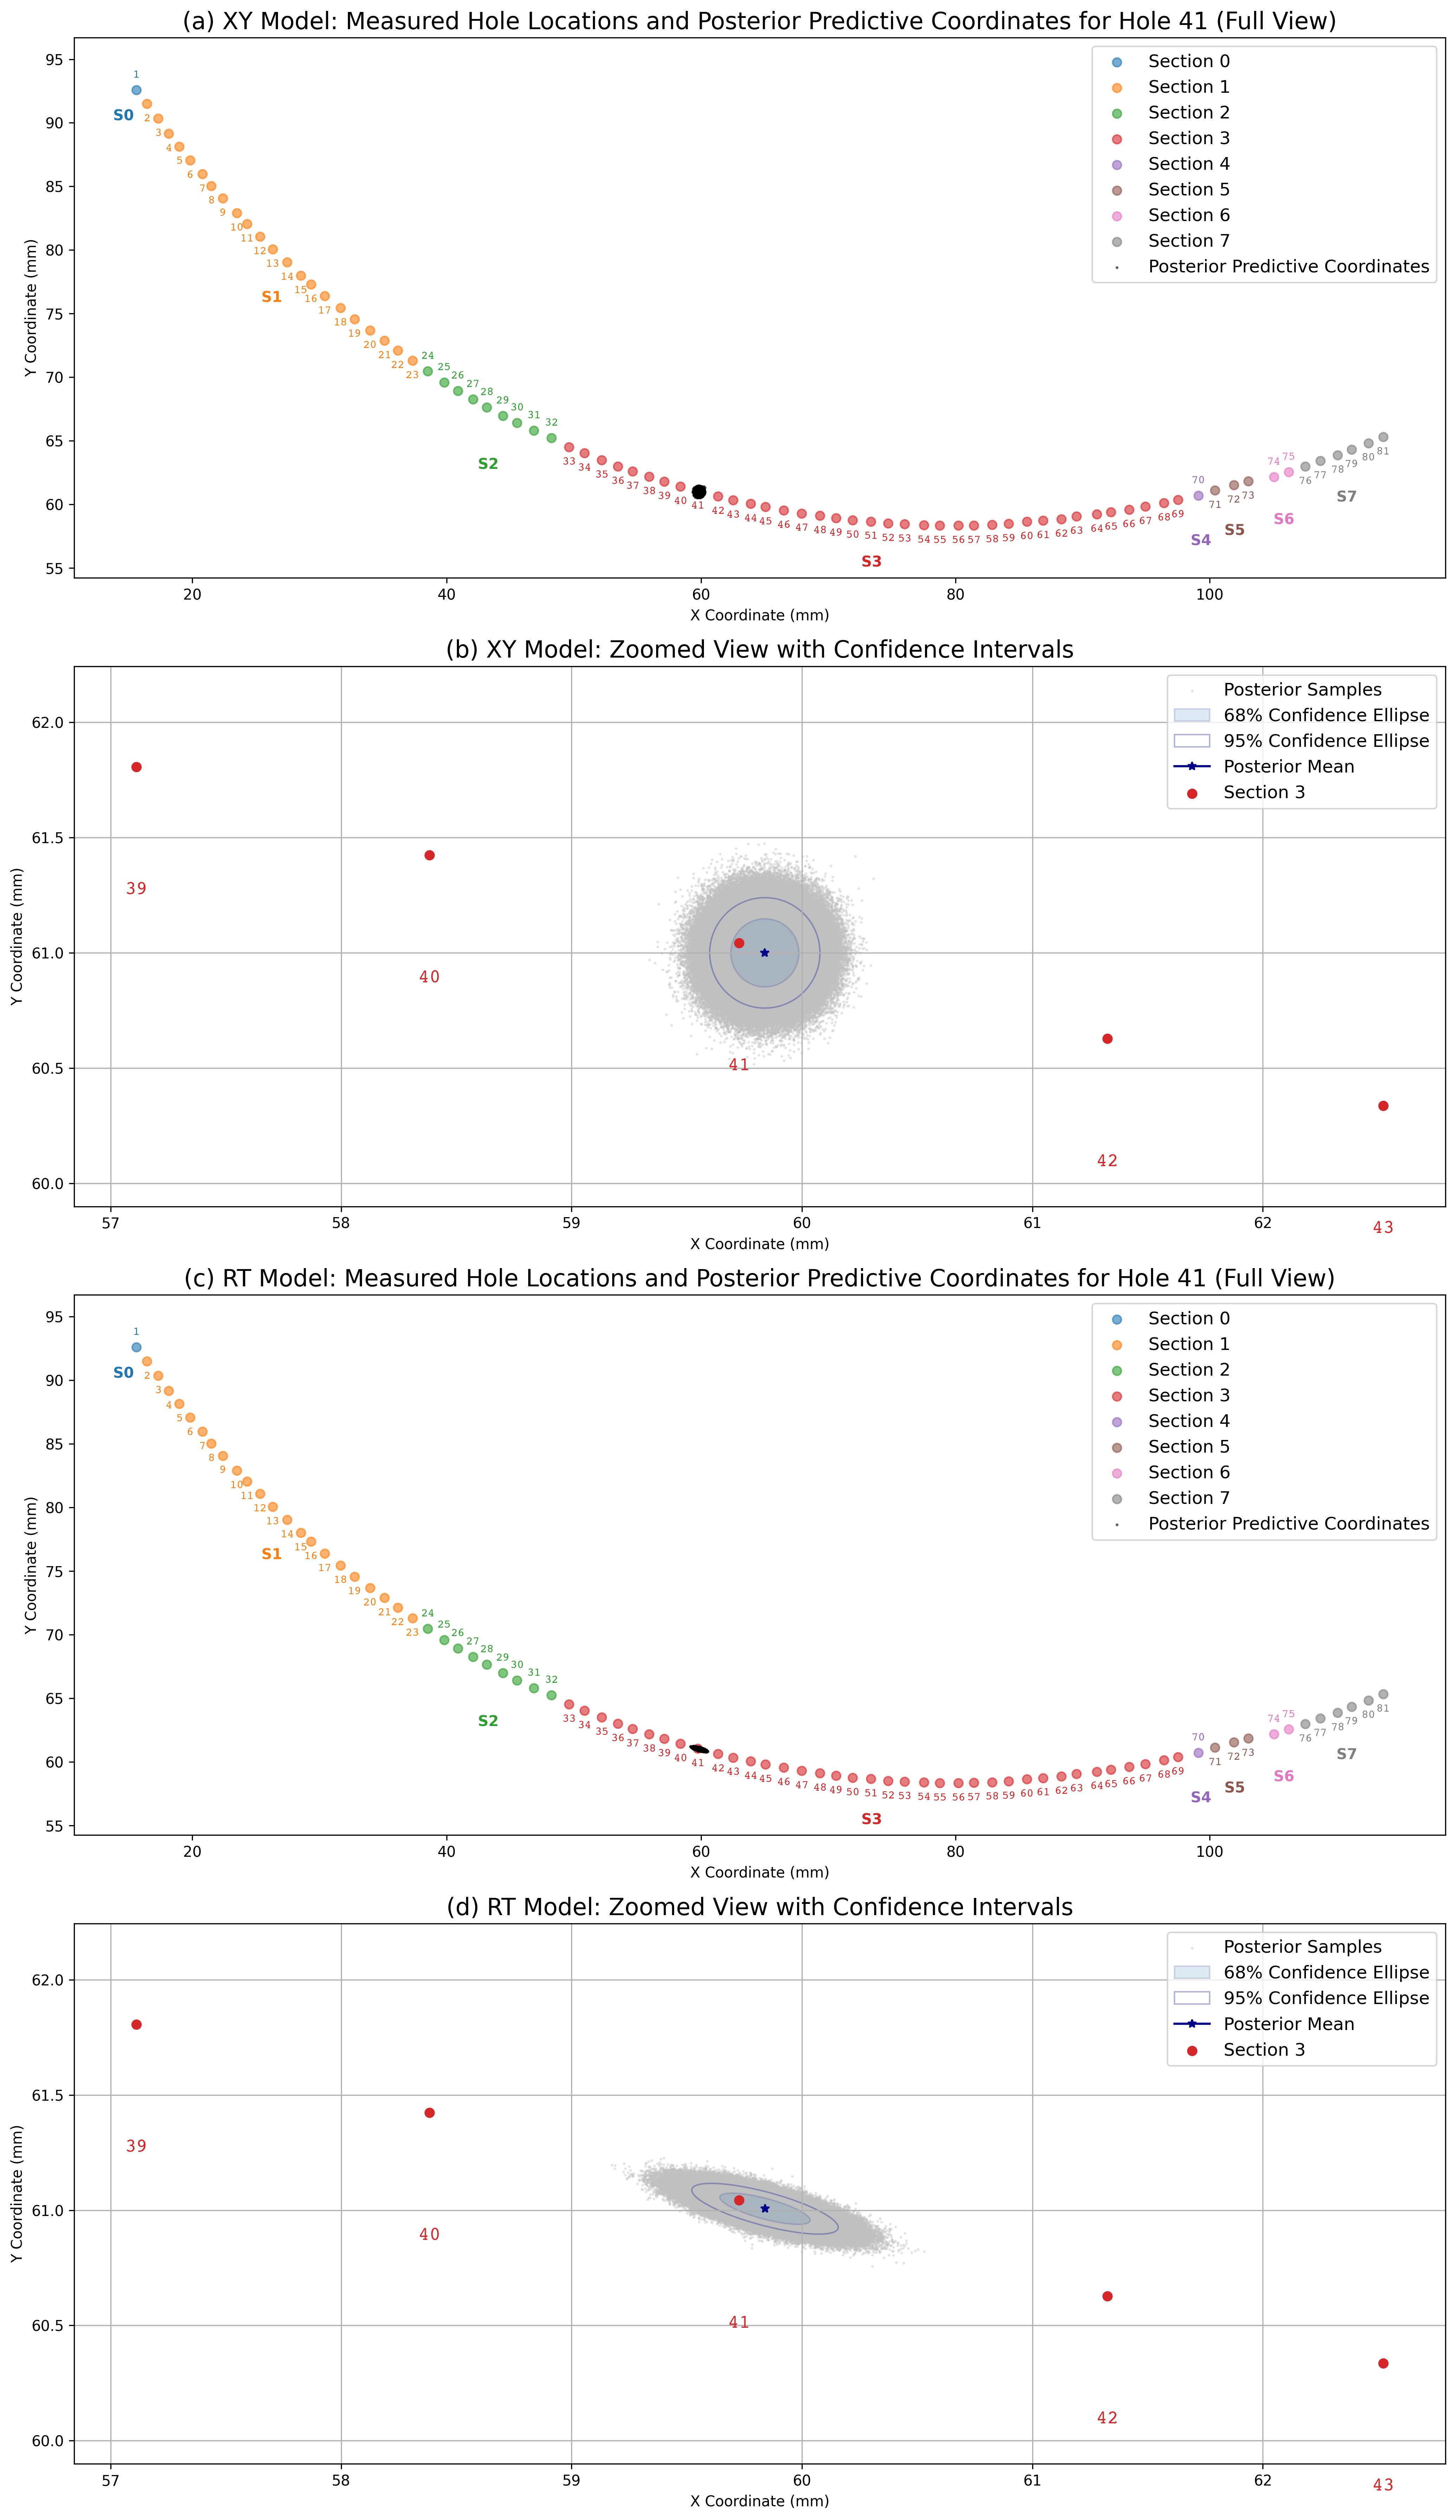

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

# Extract coordinates
x_XY, y_XY = predictive_coordinates_XY[:, 0], predictive_coordinates_XY[:, 1]
x_RT, y_RT = predictive_coordinates_RT[:, 0], predictive_coordinates_RT[:, 1]

# Color map for section annotations
cmap = plt.get_cmap("tab20")
selected_colors = [cmap(i) for i in range(0, 16, 2)]
offset = 0.8
zoom_offset = 0.5

fig, axes = plt.subplots(4, 1, figsize=(14, 24), dpi=300)
ax1, ax2, ax3, ax4 = axes

# ===============================
# (a) XY Model – Full View
# ===============================
for i, section in enumerate(sections):
    section_data = data_array[data_array[:, 0] == section]
    ax1.scatter(section_data[:, 2], section_data[:, 3],
                label=f"Section {int(section)}", color=selected_colors[i], alpha=0.6)
    for row in section_data:
        y_off = offset if section % 2 == 0 else -offset
        ax1.text(row[2], row[3] + y_off, str(int(row[1])), fontsize=8,
                 color=selected_colors[i], ha="center",
                 va="bottom" if y_off > 0 else "top", fontfamily="Courier")
    x_section, y_section = np.mean(section_data[:, 2]), np.mean(section_data[:, 3])
    x_section_offset, y_section_offset = (1, 1.5) if i == 0 else (0, 4) if i <= 3 else (-0.2, 3)
    ax1.text(x_section - x_section_offset, y_section - y_section_offset, f"S{int(section)}",
            fontsize=10, fontweight="bold", color=selected_colors[i],
            ha="center", va="top")


ax1.scatter(x_XY, y_XY, alpha=0.5, s=1, color="black", label="Posterior Predictive Coordinates")
ax1.set_title("(a) XY Model: Measured Hole Locations and Posterior Predictive Coordinates for Hole 41 (Full View)", fontsize=16)
ax1.set_xlim(10, 120)
ax1.axis("equal")
ax1.set_xlabel("X Coordinate (mm)")
ax1.set_ylabel("Y Coordinate (mm)")
ax1.legend(fontsize=12, loc="best")

# ===============================
# (b) XY Model – Zoomed View (with ellipses)
# ===============================
mask_XY = (x_XY >= 57) & (x_XY <= 63) & (y_XY >= 57) & (y_XY <= 63)
x_zoom_XY, y_zoom_XY = x_XY[mask_XY], y_XY[mask_XY]
ax2.scatter(x_zoom_XY, y_zoom_XY, alpha=0.3, s=1, color="silver", label="Posterior Samples")

coords_zoom = np.stack([x_zoom_XY, y_zoom_XY], axis=1)
if len(coords_zoom) >= 5:
    mean_x, mean_y = np.mean(coords_zoom, axis=0)
    cov = np.cov(coords_zoom.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    # 68%
    width_68, height_68 = 2 * np.sqrt(vals * 2.28)
    ellipse_68 = Ellipse((mean_x, mean_y), width_68, height_68, angle=theta,
                         edgecolor='darkblue', facecolor='#1f77b4', alpha=0.15,
                         label="68% Confidence Ellipse")
    ax2.add_patch(ellipse_68)

    # 95%
    width_95, height_95 = 2 * np.sqrt(vals * 5.991)
    ellipse_95 = Ellipse((mean_x, mean_y), width_95, height_95, angle=theta,
                         edgecolor='darkblue', facecolor='none', alpha=0.3,
                         label="95% Confidence Ellipse")
    ax2.add_patch(ellipse_95)

    ax2.plot(mean_x, mean_y, marker='*', markersize=6, color='darkblue', label="Posterior Mean")

# Section points + labels
for i, section in enumerate(sections):
    section_data = data_array[data_array[:, 0] == section]
    mask = (section_data[:, 2] >= 57) & (section_data[:, 2] <= 63) & \
           (section_data[:, 3] >= 57) & (section_data[:, 3] <= 63)
    filtered = section_data[mask]
    if len(filtered) > 0:
        ax2.scatter(filtered[:, 2], filtered[:, 3], color=selected_colors[i], label=f"Section {int(section)}")
        for row in filtered:
            y_off = zoom_offset if section % 2 == 0 else -zoom_offset
            ax2.text(row[2], row[3] + y_off, str(int(row[1])), fontsize=13,
                     color=selected_colors[i], ha="center", fontweight="bold",
                     va="bottom" if y_off > 0 else "top", fontfamily="Courier")

ax2.set_xlim(57, 63)
ax2.set_ylim(57, 63)
ax2.set_title("(b) XY Model: Zoomed View with Confidence Intervals", fontsize=16)
ax2.axis("equal")
ax2.set_xlabel("X Coordinate (mm)")
ax2.set_ylabel("Y Coordinate (mm)")
ax2.grid(True)
ax2.legend(fontsize=12)


# ===============================
# (c) RT Model – Full View
# ===============================
for i, section in enumerate(sections):
    section_data = data_array[data_array[:, 0] == section]
    ax3.scatter(section_data[:, 2], section_data[:, 3],
                label=f"Section {int(section)}", color=selected_colors[i], alpha=0.6)
    for row in section_data:
        y_off = offset if section % 2 == 0 else -offset
        ax3.text(row[2], row[3] + y_off, str(int(row[1])), fontsize=8,
                 color=selected_colors[i], ha="center",
                 va="bottom" if y_off > 0 else "top", fontfamily="Courier")
    x_section, y_section = np.mean(section_data[:, 2]), np.mean(section_data[:, 3])
    x_section_offset, y_section_offset = (1, 1.5) if i == 0 else (0, 4) if i <= 3 else (-0.2, 3)
    ax3.text(x_section - x_section_offset, y_section - y_section_offset, f"S{int(section)}",
         fontsize=10, fontweight="bold", color=selected_colors[i],
         ha="center", va="top")


ax3.scatter(x_RT, y_RT, alpha=0.5, s=1, color="black", label="Posterior Predictive Coordinates")
ax3.set_title("(c) RT Model: Measured Hole Locations and Posterior Predictive Coordinates for Hole 41 (Full View)", fontsize=16)
ax3.set_xlim(10, 120)
ax3.axis("equal")
ax3.set_xlabel("X Coordinate (mm)")
ax3.set_ylabel("Y Coordinate (mm)")
ax3.legend(fontsize=12, loc="best")

# ===============================
# (d) RT Model – Zoomed View (with ellipses)
# ===============================
mask_RT = (x_RT >= 57) & (x_RT <= 63) & (y_RT >= 57) & (y_RT <= 63)
x_zoom_RT, y_zoom_RT = x_RT[mask_RT], y_RT[mask_RT]
ax4.scatter(x_zoom_RT, y_zoom_RT, alpha=0.3, s=1, color="silver", label="Posterior Samples")

coords_zoom = np.stack([x_zoom_RT, y_zoom_RT], axis=1)
if len(coords_zoom) >= 5:
    mean_x, mean_y = np.mean(coords_zoom, axis=0)
    cov = np.cov(coords_zoom.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    # 68%
    width_68, height_68 = 2 * np.sqrt(vals * 2.28)
    ellipse_68 = Ellipse((mean_x, mean_y), width_68, height_68, angle=theta,
                         edgecolor='darkblue', facecolor='#1f77b4', alpha=0.15,
                         label="68% Confidence Ellipse")
    ax4.add_patch(ellipse_68)

    # 95%
    width_95, height_95 = 2 * np.sqrt(vals * 5.991)
    ellipse_95 = Ellipse((mean_x, mean_y), width_95, height_95, angle=theta,
                         edgecolor='darkblue', facecolor='none', alpha=0.3,
                         label="95% Confidence Ellipse")
    ax4.add_patch(ellipse_95)

    ax4.plot(mean_x, mean_y, marker='*', markersize=6, color='darkblue', label="Posterior Mean")

# Section points + labels
for i, section in enumerate(sections):
    section_data = data_array[data_array[:, 0] == section]
    mask = (section_data[:, 2] >= 57) & (section_data[:, 2] <= 63) & \
           (section_data[:, 3] >= 57) & (section_data[:, 3] <= 63)
    filtered = section_data[mask]
    if len(filtered) > 0:
        ax4.scatter(filtered[:, 2], filtered[:, 3], color=selected_colors[i], label=f"Section {int(section)}")
        for row in filtered:
            y_off = zoom_offset if section % 2 == 0 else -zoom_offset
            ax4.text(row[2], row[3] + y_off, str(int(row[1])), fontsize=13,
                     color=selected_colors[i], ha="center", fontweight="bold",
                     va="bottom" if y_off > 0 else "top", fontfamily="Courier")

ax4.set_xlim(57, 63)
ax4.set_ylim(57, 63)
ax4.set_title("(d) RT Model: Zoomed View with Confidence Intervals", fontsize=16)
ax4.axis("equal")
ax4.set_xlabel("X Coordinate (mm)")
ax4.set_ylabel("Y Coordinate (mm)")
ax4.grid(True)
ax4.legend(fontsize=12)


# Adjust layout
plt.tight_layout()
plt.show()


# Question (e)
### Implement Savage-Dickey Density Ratio

In [92]:
epsilon_samples = flat_samples_RT[:, 3] - flat_samples_RT[:, 2]

In [94]:
from scipy.stats import gaussian_kde

# Estimate the posterior density using Gaussian KDE
kde = gaussian_kde(epsilon_samples)
posterior_at_0 = kde.evaluate([0])[0]
posterior_at_0

0.0

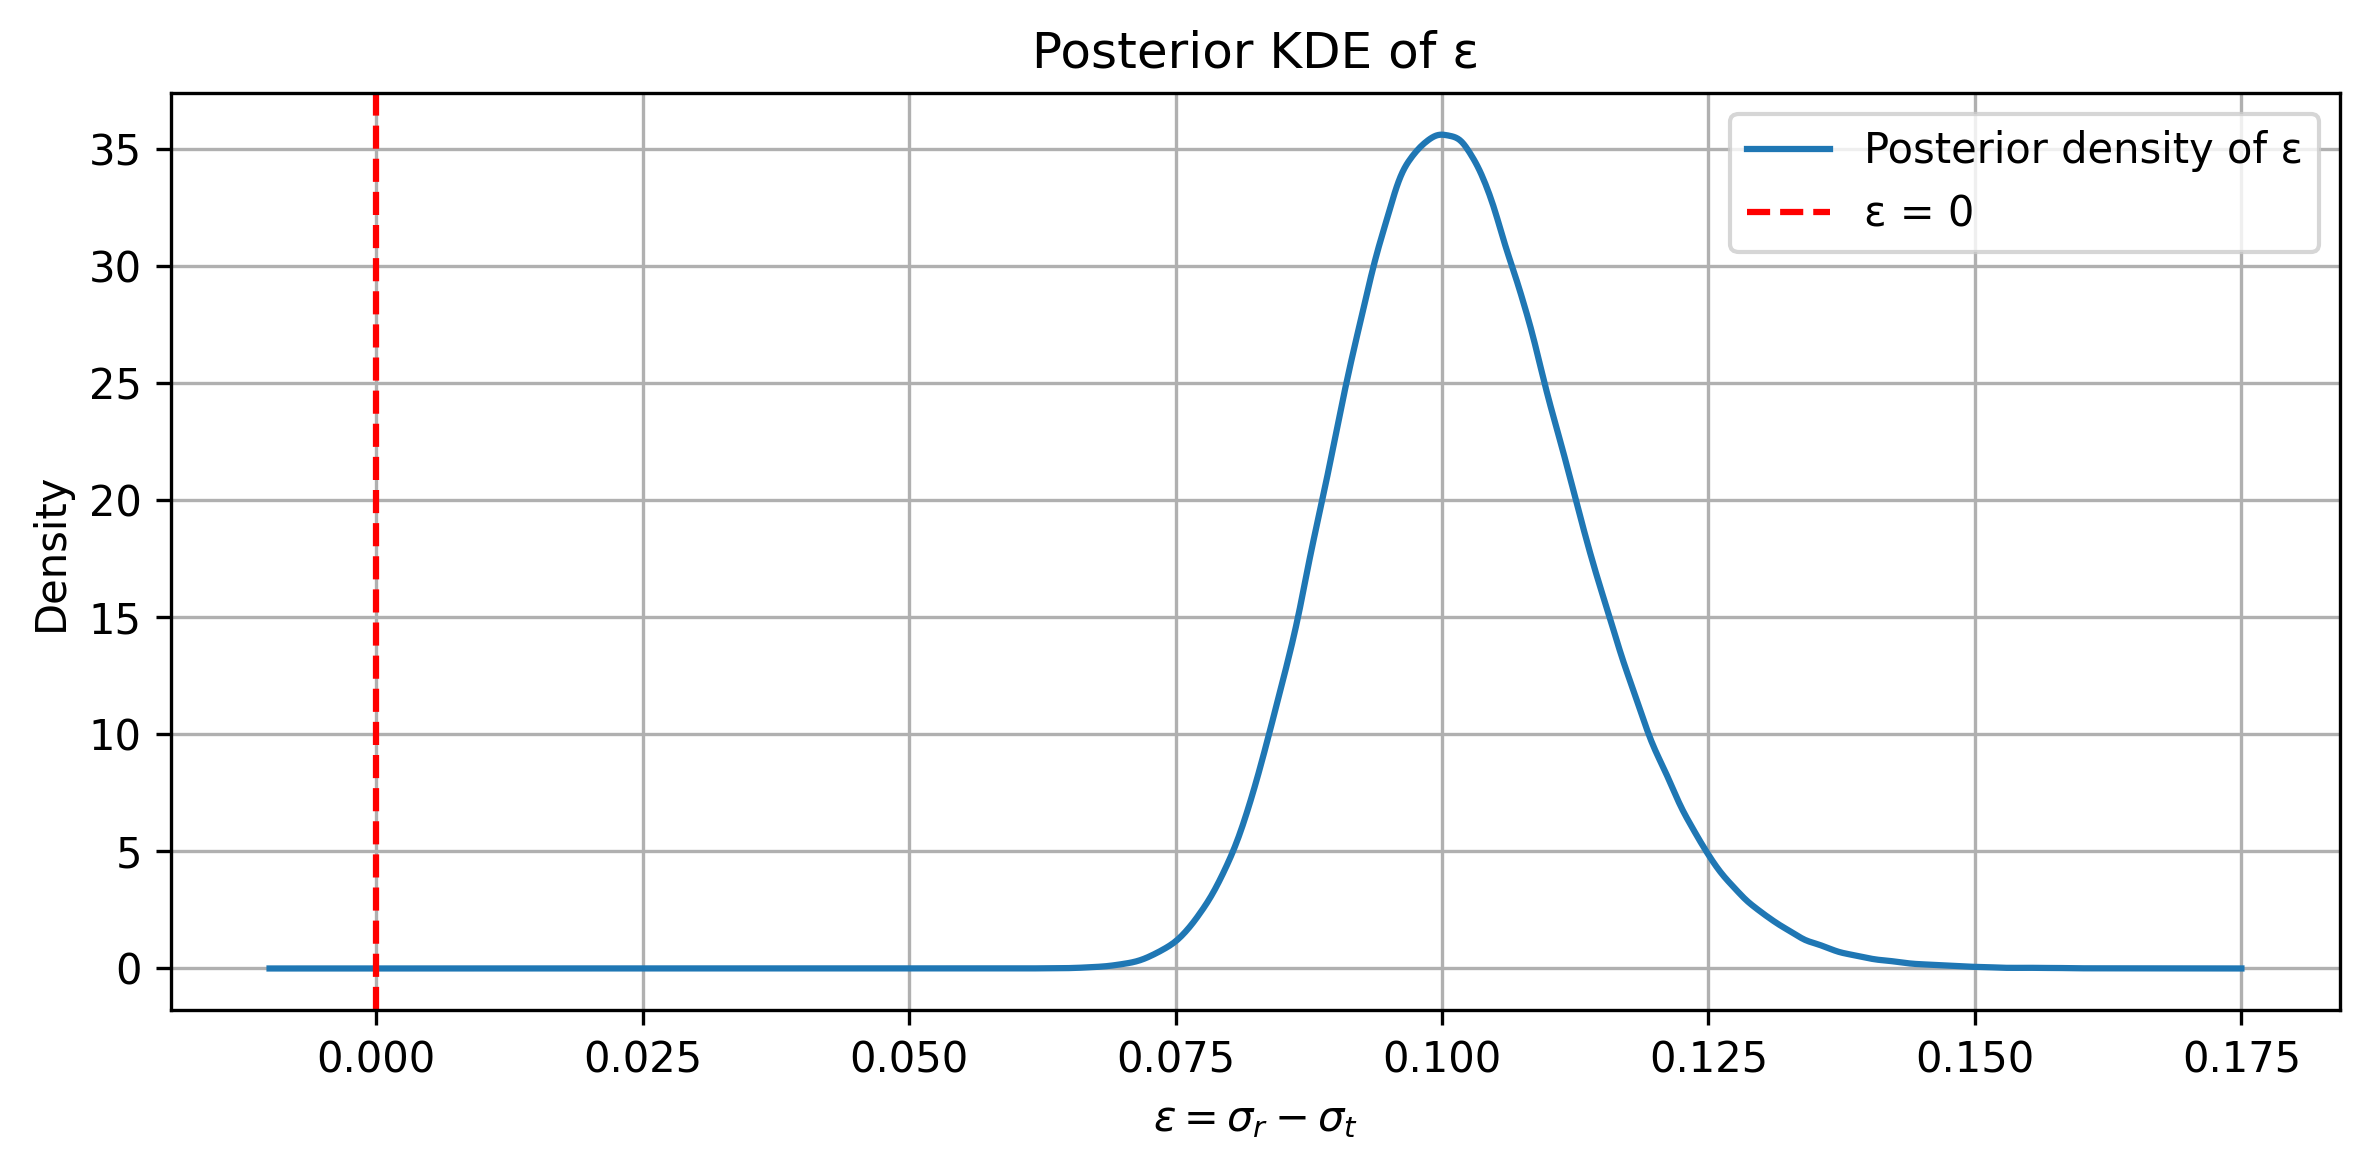

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Plot the posterior density of ε
eps_grid = np.linspace(-0.01, 0.175, 1000)
kde_values = kde.evaluate(eps_grid)

plt.figure(figsize=(8, 4), dpi=300)
plt.plot(eps_grid, kde_values, label='Posterior density of ε')
plt.axvline(0, color='red', linestyle='--', label='ε = 0')
plt.title("Posterior KDE of ε")
plt.xlabel(r"$\epsilon = \sigma_r - \sigma_t$")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
